# 010. KV キャッシュと推論の計算量(KV Cache and Inference Compute)

## 1. 概要 / Overview

自己回帰生成(autoregressive generation)では、各生成ステップで同じ Key / Value を
繰り返し計算する冗長性がある。この冗長性を取り除く **KV キャッシュ(KV Cache)** の
仕組みと、それが生成の時間計算量・メモリ量に与える影響を扱う。特に、文脈全体を
一度に処理する **prefill** と 1 トークンずつ処理する **decode** という 2 つの
フェーズの非対称性(計算律速とメモリ帯域律速)に注目し、Key / Value ヘッド数を
削減してキャッシュを縮小する MQA(Multi-Query Attention)・GQA(Grouped-Query
Attention)の効果を実験で検証する。

## 2. 参考論文 / References

1. Shazeer, N. "Fast Transformer Decoding: One Write-Head is All You Need."
   arXiv:1911.02150, 2019. https://arxiv.org/abs/1911.02150
2. Ainslie, J., Lee-Thorp, J., de Jong, M., Zemlyanskiy, Y., Lebrón, F., Sanghai, S.
   "GQA: Training Generalized Multi-Query Transformer Models from Multi-Head
   Checkpoints." EMNLP 2023. https://arxiv.org/abs/2305.13245
3. Pope, R., Douglas, S., Chowdhery, A., Devlin, J., Bradbury, J., Levskaya, A.,
   Heek, J., Xiao, K., Agrawal, S., Dean, J. "Efficiently Scaling Transformer
   Inference." MLSys 2023. https://arxiv.org/abs/2211.05102
4. Kwon, W., Li, Z., Zhuang, S., Sheng, Y., Zheng, L., Yu, C. H., Gonzalez, J. E.,
   Zhang, H., Stoica, I. "Efficient Memory Management for Large Language Model
   Serving with PagedAttention." SOSP 2023. https://arxiv.org/abs/2309.06180
   (メモリ断片化への対処。本ノートブックでは理論の位置づけとして言及するのみで、
   実装・実験の対象にはしない)

## 3. 理論 / Theory

### 3.1 自己回帰生成における再計算の冗長性

記号(このセクション共通):

- $T$: 生成するトークン数
- $L$: 層数(num_layers)
- $h$: 多頭注意機構(Multi-Head Attention)のヘッド数
- $d_{\mathrm{model}}$: モデルの隠れ次元
- $d_k$: ヘッドあたりの次元($= d_{\mathrm{model}} / h$)

003([位置エンコーディング(RoPE)](../01_foundations/003_positional_encoding_rope.ipynb))
までの`GPTLanguageModel.generate()`(006〜008)は、生成ステップ $t$ ごとに、
その時点までの系列全体(長さ $t$)を`forward()`に丸ごと渡し直す。すなわち、
ステップ $t$ の計算には以下が含まれる。

- **Query / Key / Value の線形射影**: 系列長 $t$ の入力を $d_{\mathrm{model}}
  \times d_{\mathrm{model}}$ の行列で変換するため、1 層あたり $O(t \, d_{\mathrm{model}}^2)$。
- **Attention 本体(スコア計算 + 加重和)**: $t \times t$ のスコア行列を計算するため、
  1 層あたり $O(t^2 d_{\mathrm{model}})$(ヘッド数 $h$ に分割しても
  $h \times (t^2 d_k) = t^2 (h d_k) = t^2 d_{\mathrm{model}}$ で変わらない)。

$T$ トークンを生成するには、この計算を $t = 1, \dots, T$ について毎回すべて
やり直す。$\sum_{t=1}^{T} t = O(T^2)$、$\sum_{t=1}^{T} t^2 = O(T^3)$ であるから、
1 層あたりの総計算量は

$$
\underbrace{O(T^2 d_{\mathrm{model}}^2)}_{\text{linear projections}}
+ \underbrace{O(T^3 d_{\mathrm{model}})}_{\text{attention}}
$$

(第 1 項が線形射影の総和、第 2 項が Attention 本体の総和である)

$L$ 層分では、これに $L$ を掛けた $O(L T^2 d_{\mathrm{model}}^2 + L T^3
d_{\mathrm{model}})$ になる(層数 $L$ はアーキテクチャを固定すれば定数とみなせる
ため、以降では単に $O(T^3 d_{\mathrm{model}} + T^2 d_{\mathrm{model}}^2)$ と書く)。

**KV キャッシュ** は、ステップ $t$ で計算した Key / Value を保持しておき、
ステップ $t+1$ では新規トークン 1 個分の Key / Value だけを計算して追記する
仕組みである。これにより、ステップ $t$ の計算は次で済む。

- **新規トークン分の線形射影**: 系列長 1 の入力を変換するだけなので
  $O(d_{\mathrm{model}}^2)$(定数)。
- **Attention 本体**: 新規の Query 1 個と、キャッシュ済みの長さ $t$ の
  Key / Value との内積なので $O(t \, d_{\mathrm{model}})$。

$T$ ステップの総和は $\sum_{t=1}^{T} 1 = O(T)$、$\sum_{t=1}^{T} t = O(T^2)$ から、

$$
O(T \, d_{\mathrm{model}}^2) + O(T^2 d_{\mathrm{model}})
$$

キャッシュなしの $O(T^3 d_{\mathrm{model}} + T^2 d_{\mathrm{model}}^2)$ から、
キャッシュありの $O(T^2 d_{\mathrm{model}} + T d_{\mathrm{model}}^2)$ へ、
$T$ に対する次数がそれぞれ 1 つずつ下がる。これが実験 A で検証する内容である。

下図は、1 生成ステップにおけるデータフローの違いを示す(キャッシュなしは
系列全体を毎回計算し直すのに対し、キャッシュありは新規トークン分のみを計算し
過去の結果に追記する)。

```mermaid
flowchart LR
    subgraph NOCACHE["キャッシュなし(No Cache)"]
        direction TB
        A1["トークン列(長さ t、全体)"] --> B1["全 t 個を Q, K, V に射影"]
        B1 --> C1["Attention: t × t 個のスコアを計算"]
        C1 --> D1["次トークンの logits"]
    end
    subgraph CACHE["KV キャッシュあり(With KV Cache)"]
        direction TB
        A2["新規トークン 1 個"] --> B2["新規分のみ Q, K, V に射影"]
        F2["キャッシュ済み K, V(過去 t-1 個分)"] --> E2["KeyValueCache に追記"]
        B2 --> E2
        E2 --> C2["Attention: 新規 Query 1 個 × 全 t 個の Key/Value"]
        C2 --> D2["次トークンの logits"]
    end
```

### 3.2 キャッシュのメモリ量の閉形式

記号(前節に加えて):

- $B$: バッチサイズ
- $g$: Key / Value ヘッド数(num_key_value_heads。多頭注意機構では $g = h$)
- $\text{bytes\_per\_element}$: 要素あたりバイト数(fp32 なら 4、fp16 / bf16 なら 2)

層 $l$ の KV キャッシュは、Key・Value それぞれ形状 $(B, g, T, d_k)$ のテンソルであり、
要素数は $B \, g \, T \, d_k$。Key と Value の 2 つを保持するので、1 層あたりの
バイト数は $2 \, B \, g \, T \, d_k \times \text{bytes\_per\_element}$。これを
$L$ 層分合計すると、

$$
\text{memory}
= 2 \cdot B \cdot L \cdot T \cdot (g \cdot d_k) \cdot \text{bytes\_per\_element}
$$

多頭注意機構では $g = h$ であり $g \cdot d_k = d_{\mathrm{model}}$ なので、この式は
$2 \, B \, L \, T \, d_{\mathrm{model}} \cdot \text{bytes\_per\_element}$ になる
(`compute_key_value_cache_memory_bytes`、`src/utils/statistics.py`)。系列長
$T$ に **線形** で増えることが、prefill と異なる decode 特有の性質である
(prefill 自体はキャッシュを増やすだけで、モデル本体の計算量が $T$ に対して
線形に留まるわけではない。3.1 節参照)。

In [1]:
# 環境セットアップ(Google Colab)
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    get_ipython().system("git clone https://github.com/kojikojiprg/ai-theories.git")
    get_ipython().run_line_magic("cd", "ai-theories")
    get_ipython().system("pip install uv -q")
    get_ipython().system("uv pip install --system -r requirements.txt")
# ローカル(Jupyter)実行時は、リポジトリルートで起動していればそのまま動く。

import functools
import hashlib
import json
import platform
import shutil
import subprocess
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

from src.data.text import (
    encode_corpus,
    load_wikipedia_corpus_with_fallback,
    make_evaluation_windows,
    split_train_val_text,
)
from src.data.tokenizer import load_bpe_id_tokenizer_from_hub
from src.generation.cache import KeyValueCache
from src.layers.attention import MultiHeadAttention, create_causal_mask
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.gpt import GPTLanguageModel, convert_attention_to_grouped_query
from src.training.trainer import evaluate_bits_per_byte, train_language_model
from src.utils.statistics import (
    compute_arithmetic_intensity,
    compute_key_value_cache_memory_bytes,
    count_non_embedding_parameters,
    fit_power_law_exponent,
)
from src.utils.visualization import plot_log_log_fit

ROOT = Path(".")

SMOKE_TEST = True  # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)
# 時間計測(実験 A・B・C・D)専用のデバイス。実験 B・C は decode がメモリ帯域律速で
# あること(GPU 固有の性質)そのものを検証するため、CUDA が使える環境では必ず CUDA を
# 使う(DEVICE をそのまま使う)。この Mac の MPS バックエンドは、本ノートブックのような
# 小さいテンソルに対するカーネル起動オーバーヘッドが大きく、変動係数(CV)が前提条件
# P0(0.1 以下)を安定して満たさない(ローカルで実測済み)ため、MPS のときのみ CPU に
# 落とす(CPU は決定的で高速なため P0 を安定して満たせる。Claude Code によるローカル
# 実行(第 1 段階)はこの経路を通る)。Google Colab T4 GPU での本番実行(第 2 段階)は
# CUDA が使えるため、DEVICE(= cuda)がそのまま使われる。
TIMING_DEVICE = DEVICE if DEVICE.type == "cuda" else torch.device("cpu")

# 実験 A・B・C 共通のウォームアップ反復回数(前提条件 P0)。CUDA カーネルの
# コンパイル・初回起動コストを計測区間から除くため、計測前に複数回実行して
# 捨てる。反復回数を増やしても変動係数(CV、個々の測定値のばらつき)自体は
# 縮まらない(CV が縮むのは平均の標準誤差であって個々の測定値の散らばりでは
# ないため)。P0 が主張しているのは「ウォームアップ後に計測すること」であり、
# ウォームアップが不十分だと初回起動コストの残滓が測定値に混入して CV を
# 押し上げる。したがってウォームアップ回数を増やすことは、P0 への対処として
# 反復回数を増やすこととは異なる(7.1 節参照)。
WARMUP_REPEATS = 3

# --- 実験 A・B・C・D の水準・反復回数(スモーク値と本番値を SMOKE_TEST で切り替える) ---
# ここに集約し、各実験のセル内には水準の数値を直接書かない。SMOKE_TEST を切り替える
# だけで全実験が本番水準に切り替わることを保証するのが目的である(以前は
# PRODUCTION_* 定数が外挿の見積もりにしか使われず、SMOKE_TEST=False でも実際の
# 実験がスモーク水準のまま完了してしまう不具合があった)。

# 実験 A(7.2 節): KV キャッシュによる生成時間の次数の低下。生成長 T の水準・反復回数。
SMOKE_A_T_LEVELS = [16, 32, 64, 128, 256]  # 等比刻み
PRODUCTION_A_T_LEVELS = [128, 256, 512, 1024, 2048]  # 等比刻み
# SMOKE_A_REPEATS は 6(P0-a が先頭 3 反復・末尾 3 反復の非重複比較として定義できる
# 最小値、7.1 節参照)以上にする必要があるため 5 から引き上げた(仮説・水準とは無関係な、
# P0-a の定義上の制約による)。PRODUCTION_A_REPEATS は今回の観測値からの見積もりで
# P0-b(標準誤差が平均の 5% 以下)を満たす見込みのため、15 から変更しない(7.1.1 節参照)。
SMOKE_A_REPEATS = 6
PRODUCTION_A_REPEATS = 10
A_T_LEVELS = PRODUCTION_A_T_LEVELS if not SMOKE_TEST else SMOKE_A_T_LEVELS
A_REPEATS = PRODUCTION_A_REPEATS if not SMOKE_TEST else SMOKE_A_REPEATS

# 実験 B(7.3 節): decode のバッチサイズ依存性の差。バッチサイズの水準・反復回数。
SMOKE_B_LEVELS = [1, 2, 4, 8, 16]  # 等比刻み
PRODUCTION_B_LEVELS = [1, 4, 16, 64, 256]  # 等比刻み
SMOKE_B_REPEATS = 7
# PRODUCTION_B_REPEATS は 15 から 30 に引き上げた。今回の観測値(decode_B4 の変動係数
# 0.1922)からの見積もりでは、反復 15 回では標準誤差が平均の 5.0% となり P0-b の閾値
# ぎりぎりだったため(7.1.1 節参照、前提条件に関する量に基づく判断であり検証したい
# 仮説の方向には依存しない)。
PRODUCTION_B_REPEATS = 30
B_LEVELS = PRODUCTION_B_LEVELS if not SMOKE_TEST else SMOKE_B_LEVELS
B_REPEATS = PRODUCTION_B_REPEATS if not SMOKE_TEST else SMOKE_B_REPEATS
# prefill 長は SMOKE_TEST に関わらず本番値のまま固定する(バッチサイズを縮小しても
# この実験の計算量は十分小さいため、prefill 長は縮小せず本番と一致させる。
# 条件間で厳密に一致させる設計の値は縮小後も一致させる、という縮小規則に沿う。
# プロンプト A のレビューで、prefill 長を縮小したまま本番バッチサイズへ外挿すると、
# prefill の 1 回あたりコスト(B * S * d_model * (d_model + S) に比例)のうち S の
# 効果が外挿から抜け落ちることが判明したため、この節で修正した)。
PRODUCTION_B_PREFILL_LEN = 512
B_PREFILL_LEN = PRODUCTION_B_PREFILL_LEN

# 実験 C(7.4 節): Key / Value ヘッド数の削減による高速化の系列長依存性。
# 生成長 T の両端(等比刻み)・反復回数。
SMOKE_C_T_SMALL, SMOKE_C_T_LARGE = 16, 256  # 等比刻みの両端
PRODUCTION_C_T_SMALL, PRODUCTION_C_T_LARGE = 64, 4096  # 等比刻みの両端
SMOKE_C_REPEATS = 7
PRODUCTION_C_REPEATS = 15
C_T_SMALL, C_T_LARGE = (
    (PRODUCTION_C_T_SMALL, PRODUCTION_C_T_LARGE)
    if not SMOKE_TEST
    else (SMOKE_C_T_SMALL, SMOKE_C_T_LARGE)
)
C_REPEATS = PRODUCTION_C_REPEATS if not SMOKE_TEST else SMOKE_C_REPEATS

# 実験 D(7.5 節): GQA への変換における平均プール初期化の効果。追加学習ステップ数。
SMOKE_D_NUM_STEPS = 15
PRODUCTION_D_NUM_STEPS = 300
D_NUM_STEPS = PRODUCTION_D_NUM_STEPS if not SMOKE_TEST else SMOKE_D_NUM_STEPS
# 実験 D の学習データ量(文字数)は d_train_text(5.3 節でコーパス取得後に確定)に
# 依存するため、ここでは smoke 側の定数のみを定義する。本番側は「d_train_text 全体」
# であり定数化できない(D_TRAIN_TEXT_CHARS = SMOKE_D_TRAIN_TEXT_CHARS if SMOKE_TEST
# else len(d_train_text) として、d_train_text が確定した時点(5.3 節)で導出する)。
SMOKE_D_TRAIN_TEXT_CHARS = 400_000

# P0-a(7.1 節)は先頭 3 反復・末尾 3 反復を重複なく比較するため、反復回数が
# 3 の 2 倍(6)未満の条件では定義できない。実験 A・B・C の反復回数(SMOKE・
# PRODUCTION のいずれも)がこの最小値を満たすことを、実験の計測に進む前に確認する。
for _name, _repeats in (
    ("SMOKE_A_REPEATS", SMOKE_A_REPEATS),
    ("PRODUCTION_A_REPEATS", PRODUCTION_A_REPEATS),
    ("SMOKE_B_REPEATS", SMOKE_B_REPEATS),
    ("PRODUCTION_B_REPEATS", PRODUCTION_B_REPEATS),
    ("SMOKE_C_REPEATS", SMOKE_C_REPEATS),
    ("PRODUCTION_C_REPEATS", PRODUCTION_C_REPEATS),
):
    assert _repeats >= 6, (
        f"{_name}={_repeats} は P0-a(先頭 3 反復・末尾 3 反復の非重複比較)が定義可能な"
        "最小値 6 未満である。反復回数を 6 以上にすること。"
    )


def sync(device: torch.device) -> None:
    '''時間計測の前後で呼ぶデバイス同期(前提条件 P0)。'''
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def is_oom_error(exc: BaseException) -> bool:
    '''out-of-memory 例外の判定(``torch.OutOfMemoryError``は PyTorch 2.5 以降の
    属性であり、Colab のバージョンによっては存在しない場合があるため、例外の
    クラス名・メッセージ文字列でも判定できるようにする)。
    '''
    name = type(exc).__name__
    return "OutOfMemory" in name or "out of memory" in str(exc).lower()


def warn_if_unreliable_fit(fit, name: str) -> None:
    '''べき乗則あてはめの標準誤差が推定値と同程度以上の場合に警告を出力する。
    外挿が信用できない状態を、合計値へ静かに混ぜないための安全弁。
    '''
    if fit.exponent_stderr >= abs(fit.exponent):
        print(
            f"[警告] {name} のべき指数の標準誤差({fit.exponent_stderr:.3f})が推定値"
            f"({fit.exponent:.3f})と同程度以上であり、この外挿は信用できない。"
            "水準・反復回数を増やして再計測すること。"
        )


P0A_MAX_DRIFT_SIGMA = 2.0  # P0-a: 先頭・末尾平均の差の許容量(全反復の標準偏差の倍数)
P0B_MAX_RELATIVE_STDERR = 0.05  # P0-b: 平均の標準誤差の許容量(平均に対する比率)


def compute_p0a(values) -> dict:
    '''P0-a(ウォームアップの担保)を計算する。先頭 3 反復の平均と末尾 3 反復の平均の
    差が、全反復の標準偏差(ddof=1)の P0A_MAX_DRIFT_SIGMA 倍以内かを見る。ウォームアップ
    不足による系統的なドリフト(反復を重ねるにつれ値が単調に変化する)を直接検出する
    指標であり、絶対時間の大小には依存しない(7.1 節参照)。``values``の長さは 6 以上
    であること(呼び出し前にセットアップセルでアサーション済み)。
    '''
    arr = np.array(values)
    assert len(arr) >= 6, f"P0-a には反復回数 6 以上が必要: {len(arr)}"
    head_mean = float(arr[:3].mean())
    tail_mean = float(arr[-3:].mean())
    diff = abs(tail_mean - head_mean)
    std_all = float(arr.std(ddof=1))
    threshold = P0A_MAX_DRIFT_SIGMA * std_all
    return {
        "head_mean": head_mean,
        "tail_mean": tail_mean,
        "diff": diff,
        "std_all": std_all,
        "threshold": threshold,
        "holds": bool(diff <= threshold),
    }


def compute_p0b(values) -> dict:
    '''P0-b(判定精度の担保)を計算する。平均の標準誤差(標準偏差(ddof=1) / sqrt(反復回数))
    が平均の P0B_MAX_RELATIVE_STDERR(5%)以下かを見る。対比量の推定に使う各測定の
    平均が十分な精度で求まっていることを担保する指標である(7.1 節参照)。
    '''
    arr = np.array(values)
    n = len(arr)
    mean_val = float(arr.mean())
    std_val = float(arr.std(ddof=1))
    stderr = std_val / (n**0.5)
    ratio = stderr / mean_val
    return {
        "mean": mean_val,
        "std": std_val,
        "stderr": stderr,
        "ratio": ratio,
        "holds": bool(ratio <= P0B_MAX_RELATIVE_STDERR),
    }


print(f"torch: {torch.__version__} / DEVICE: {DEVICE} / TIMING_DEVICE: {TIMING_DEVICE}")
print(f"SMOKE_TEST: {SMOKE_TEST} / WARMUP_REPEATS: {WARMUP_REPEATS}")
if TIMING_DEVICE.type != "cuda":
    print(
        "[注記] TIMING_DEVICE が CUDA ではない。実験 B・C の "
        "「decode はメモリ帯域律速」という仮説自体が GPU 固有の性質であるため、"
        "CUDA 環境(Google Colab T4 GPU)で再実行するまでは結果を確定させないこと。"
    )

# --- 実効水準の一覧(このセルの出力だけで、本番水準で走っているか判断できるようにする) ---
print(f"\n[実効水準] SMOKE_TEST={SMOKE_TEST}(True ならスモーク値、False なら本番値)")
print(f"  実験 A: A_T_LEVELS={A_T_LEVELS}, A_REPEATS={A_REPEATS}")
print(f"  実験 B: B_LEVELS={B_LEVELS}, B_REPEATS={B_REPEATS}, "
      f"B_PREFILL_LEN={B_PREFILL_LEN}(常に本番値に固定)")
print(f"  実験 C: C_T_SMALL={C_T_SMALL}, C_T_LARGE={C_T_LARGE}, C_REPEATS={C_REPEATS}")
print(f"  実験 D: D_NUM_STEPS={D_NUM_STEPS}, "
      f"D_TRAIN_TEXT_CHARS={'(コーパス取得後に確定)' if not SMOKE_TEST else SMOKE_D_TRAIN_TEXT_CHARS}")

torch: 2.13.0 / DEVICE: mps / TIMING_DEVICE: cpu
SMOKE_TEST: True / WARMUP_REPEATS: 3
[注記] TIMING_DEVICE が CUDA ではない。実験 B・C の 「decode はメモリ帯域律速」という仮説自体が GPU 固有の性質であるため、CUDA 環境(Google Colab T4 GPU)で再実行するまでは結果を確定させないこと。

[実効水準] SMOKE_TEST=True(True ならスモーク値、False なら本番値)
  実験 A: A_T_LEVELS=[16, 32, 64, 128, 256], A_REPEATS=6
  実験 B: B_LEVELS=[1, 2, 4, 8, 16], B_REPEATS=7, B_PREFILL_LEN=512(常に本番値に固定)
  実験 C: C_T_SMALL=16, C_T_LARGE=256, C_REPEATS=7
  実験 D: D_NUM_STEPS=15, D_TRAIN_TEXT_CHARS=400000


### 3.3 prefill と decode の非対称性

本トピックの中心的な洞察は、生成の 2 つのフェーズ **prefill**(起点となる文脈
全体を 1 回の順伝播でまとめて処理する)と **decode**(KV キャッシュを使い、
新規トークン 1 個ずつを逐次処理する)が、計算資源の使われ方の点で対称ではない
ことである。

**演算強度(arithmetic intensity)** は、ある演算が読み書きするメモリの
バイト数に対する浮動小数点演算回数(FLOPs)の比

$$
\text{AI} = \frac{\text{FLOPs}}{\text{bytes moved}}
$$

で定義される(`compute_arithmetic_intensity`)。roofline モデル(Williams et al.,
"Roofline: An Insightful Visual Performance Model for Multicore Architectures",
CACM 2009)では、ハードウェアごとに定まる **ridge point**

$$
\text{AI}_{\text{ridge}} = P_{\text{peak}} / BW
$$

を境に演算の律速要因が切り替わる($P_{\text{peak}}$ はハードウェアのピーク演算性能
(FLOPS)、$BW$ はメモリ帯域幅(bytes/s))。ridge point より演算強度が低い演算は、
演算器がメモリからのデータ供給を待つ **メモリ帯域律速(memory-bound)** になり、
高い演算はメモリ帯域が余っていても演算器が追いつかない **計算律速(compute-bound)**
になる。

線形層(重み $(d_{\text{in}}, d_{\text{out}})$、入力 $N$ 行、要素あたり
$\text{bytes\_per\_element}$ バイト)を例にとる。

- FLOPs: $2 N d_{\text{in}} d_{\text{out}}$(積和 1 回を 2 演算と数える標準的な近似)
- bytes moved: 重みの読み出し $d_{\text{in}} d_{\text{out}} \cdot
  \text{bytes\_per\_element}$ + 入出力活性化の読み書き
  $N (d_{\text{in}} + d_{\text{out}}) \cdot \text{bytes\_per\_element}$

**prefill**($N = B \cdot S$、$S$ は文脈全体の系列長)では、$N$ が大きいほど
FLOPs は $N$ に比例して増える一方、重みの読み出しバイト数は $N$ によらず一定
(1 回の呼び出しにつき 1 回だけ読む)ため、$N$ が大きいほど演算強度は大きくなる
(重みの読み出しコストが多くの演算で「償却」される)。

**decode**($N = B$、系列長 1 の新規トークンのみ)では、$B$ が小さい典型的な
生成では $N$ が小さく、重みバイト数が総バイト数の大部分を占め続ける。1 ステップ
ごとに同じ重みを読み直すコストを、そのステップの少ない演算量では償却できない
ため、演算強度は低いまま(概ね $O(B)$、$B=1$ では $O(1)$)に留まる。

このため decode はメモリ帯域律速になりやすく、KV キャッシュのメモリ量(3.2 節)を
減らすこと(MQA・GQA)が、decode の速度に直接効いてくる。実験 B は、この非対称性を
バッチサイズ依存性の差として検証する。

In [2]:
# 数値例: 線形層 1 個(d_in = d_out = D_MODEL)の演算強度を、decode(N=1)と
# prefill(N=系列長)で比較する。d_model・要素あたりバイト数は本ノートブック共通の
# 本番モデル構成(6 節)を先取りして使う。
_EXAMPLE_D_MODEL = 256
_EXAMPLE_BYTES_PER_ELEMENT = 4  # fp32
_weight_bytes = _EXAMPLE_D_MODEL * _EXAMPLE_D_MODEL * _EXAMPLE_BYTES_PER_ELEMENT


def _linear_layer_ai(n: int) -> float:
    flops = 2 * n * _EXAMPLE_D_MODEL * _EXAMPLE_D_MODEL
    activation_bytes = n * 2 * _EXAMPLE_D_MODEL * _EXAMPLE_BYTES_PER_ELEMENT
    bytes_moved = _weight_bytes + activation_bytes
    return compute_arithmetic_intensity(flops, bytes_moved)


ai_decode = _linear_layer_ai(1)  # decode: B=1, 系列長 1
ai_prefill_256 = _linear_layer_ai(256)  # prefill: 系列長 256
print(f"演算強度(decode, N=1):    {ai_decode:.3f} FLOPs/byte")
print(f"演算強度(prefill, N=256): {ai_prefill_256:.3f} FLOPs/byte")
print(f"比(prefill / decode): {ai_prefill_256 / ai_decode:.1f} 倍")

# 診断量: T4 GPU の公称値(FP32 ピーク ~8.1 TFLOPS、メモリ帯域 ~320 GB/s)との対比。
# この絶対値の一致は判定基準にしない(実測の達成帯域は公称値の 7 割前後であり、
# 真偽を判定できる形にはならない。CLAUDE.md の実験 B 宣言セル参照)。
_T4_PEAK_FLOPS = 8.1e12
_T4_BANDWIDTH_BYTES_PER_SEC = 320e9
_t4_ridge_point = _T4_PEAK_FLOPS / _T4_BANDWIDTH_BYTES_PER_SEC
print(f"\n[診断量] T4 GPU の ridge point(公称値): {_t4_ridge_point:.2f} FLOPs/byte")
print(f"[診断量] decode の演算強度は ridge point の {ai_decode / _t4_ridge_point:.1%}")
print(f"[診断量] prefill(N=256) の演算強度は ridge point の {ai_prefill_256 / _t4_ridge_point:.1%}")

演算強度(decode, N=1):    0.496 FLOPs/byte
演算強度(prefill, N=256): 42.667 FLOPs/byte
比(prefill / decode): 86.0 倍

[診断量] T4 GPU の ridge point(公称値): 25.31 FLOPs/byte
[診断量] decode の演算強度は ridge point の 2.0%
[診断量] prefill(N=256) の演算強度は ridge point の 168.6%


### 3.4 MQA(Multi-Query Attention)と GQA(Grouped-Query Attention)

3.2 節の閉形式が示す通り、KV キャッシュのメモリ量は Key / Value ヘッド数 $g$ に
比例する。Shazeer (2019) の **MQA** は $g = 1$(全ての Query ヘッドが単一の
Key / Value ヘッドを共有する)、Ainslie et al. (2023) の **GQA** はその中間
($1 < g < h$、Query ヘッドを $h/g$ 個ずつのグループに分け、グループ内で
Key / Value ヘッドを共有する)を提案した。いずれも、キャッシュのメモリ量を
$g/h$ 倍に縮小する(Query 側の射影 $W^Q$・出力射影 $W^O$ は変更しない)。

```mermaid
flowchart TB
    subgraph MHA["多頭注意機構(h=8, g=8)"]
        direction LR
        mq1["Query head 1"] --- mk1["KV head 1"]
        mq2["Query head 2"] --- mk2["KV head 2"]
        mqd["..."] --- mkd["..."]
        mq8["Query head 8"] --- mk8["KV head 8"]
    end
    subgraph GQA["GQA(h=8, g=4)"]
        direction LR
        gq12["Query head 1, 2"] --> gk1["KV head 1"]
        gq34["Query head 3, 4"] --> gk2["KV head 2"]
        gq56["Query head 5, 6"] --> gk3["KV head 3"]
        gq78["Query head 7, 8"] --> gk4["KV head 4"]
    end
    subgraph MQA["MQA(h=8, g=1)"]
        direction LR
        mqall["Query head 1..8(全て)"] --> mk["KV head 1"]
    end
```

**uptraining**(Ainslie et al., 2023): 既存の多頭注意機構チェックポイントから
GQA / MQA へ変換する際、Key / Value の射影行列をランダムに初期化すると、
学習済みの Query・出力射影との整合が崩れ、追加学習の初期の損失が大きく跳ね上がる。
Ainslie らは、グループ内の元の Key / Value ヘッドの重みを **平均プール
(mean pooling)** して初期化する方法を提案し、ランダム初期化より少ない追加学習
ステップ数で高い性能に到達することを示した(`convert_attention_to_grouped_query`
の`init="mean_pool"`、実験 D で検証する)。

### 3.5 RoPE とキャッシュの相互作用

003([位置エンコーディング(RoPE)](../01_foundations/003_positional_encoding_rope.ipynb))
で導入した RoPE(Rotary Position Embedding、Su et al., Neurocomputing 2024)は、
Query・Key の各トークンをその **絶対位置** $m$ だけ回転させる
(`RotaryPositionEmbedding.apply`)。この回転は他のトークンの値に一切依存しない
(トークン $m$ の回転は $m$ だけで決まる)ため、系列全体をまとめて回転させても、
1 トークンずつ回転させて後から連結しても、結果は完全に同じになる。

これが、KV キャッシュと RoPE の相互作用の核心である。decode の各ステップで
新規トークンに RoPE を適用する際、**その系列内での相対位置(常に 0)ではなく、
キャッシュ長だけずれた絶対位置** を使う必要がある。003 の時点で
`MultiHeadAttention.forward`・`RotaryPositionEmbedding.apply`・`DecoderBlock.forward`
はいずれも`positions`引数(Query の絶対位置インデックス)を既に持っており、
docstring にも「KV キャッシュを用いた逐次推論(トピック 010)では、生成の各
ステップで Query の絶対位置がキャッシュ長だけずれるため、これを外部から指定
できるようにしている」と明記されていた。010 の実装(`GPTLanguageModel.generate`
の`use_cache=True`パス)は、この 003 の設計をそのまま使う。具体的には、prefill
ステップでは`positions = arange(S_0)`、decode の各ステップでは
`positions = [kv_cache.length]`(その時点のキャッシュ長)を渡す。

## 4. 実装方針 / Implementation Policy

**ノートブック内に直接書くもの**(`src/`に置かない): 3.1 節の導入として、
Attention 層自身が過去の Key / Value を保持する最小実装
(`MinimalCachedAttention`、20 行程度)。状態を層の外に出す設計上の理由
(条件・シードをまたぐ計測での状態漏れ、メモリ量集計の分散)を実装と対比して
示すためだけの教育的なコードであり、後続トピックから import されない。

**`src/`に置くもの**:

- `src/generation/cache.py`(新規): `KeyValueCache`。層ごとの Key / Value の
  保持・追記・メモリ量の報告を行う。014(Flash Attention)・015(長文脈拡張)・
  016 以降の生成による評価から再利用される前提。
- `src/layers/attention.py`: `MultiHeadAttention`に`num_key_value_heads`引数
  (既定値`None`で多頭注意機構と完全に同一の挙動)と KV キャッシュの入出力
  (`kv_cache`・`layer_idx`引数)を追加。
- `src/layers/transformer_block.py`: `DecoderBlock.forward`に`kv_cache`・
  `layer_idx`引数を追加し、`self_attn`へそのまま透過する。
- `src/models/gpt.py`: `GPTLanguageModel.forward`に`kv_cache`引数、
  `generate()`に`use_cache`引数(既定値`False`で 006〜008 と完全に同一の挙動)を
  追加。多頭注意機構の重みから GQA / MQA への変換関数
  `convert_attention_to_grouped_query`(平均プール初期化・ランダム初期化の
  両方に対応)を追加。
- `src/utils/statistics.py`: `compute_key_value_cache_memory_bytes()`・
  `compute_arithmetic_intensity()`・`fit_power_law_exponent()`(回帰係数と
  その標準誤差を返す)。
- `src/utils/visualization.py`: `plot_log_log_fit()`(両対数プロット、
  べき乗則あてはめの直線を重畳できる)。

後方互換性(`num_key_value_heads=None`・`use_cache=False`のとき 006〜009 と
完全に同一の挙動になること)は、乱数消費まで含めて bit-identical であることを
既に検証済みである(`MultiHeadAttention`・`GPTLanguageModel`のパラメータ初期化・
順伝播の出力ハッシュが、本トピック追加前のコードと完全一致することを、実装の
過程で確認した。6 節の不変条件アサーションで改めて示す)。

## 5. 実装 / Implementation

### 5.1 最小実装: Attention 層自身が Key / Value を保持する

まず、状態(過去の Key / Value)を Attention 層自身に持たせる最小実装
(`MinimalCachedAttention`)を示す。次のセルで`src/generation/cache.py`の
`KeyValueCache`(状態を層の外に出した実装)と生成結果を比較し、**なぜ状態を層の
外に出すのか** を実装の対比を通じて示す。

- **条件・シードをまたぐ計測での状態漏れ**: `MinimalCachedAttention`はインスタンス
  自身が`cache_k`・`cache_v`を保持するため、同じレイヤーインスタンスを複数の
  条件・シードで使い回すと、前の生成のキャッシュが残ったまま次の計測を始めて
  しまう危険がある(`reset_cache()`の呼び忘れが静かなバグになる)。`KeyValueCache`
  は呼び出し側が明示的に生成・破棄するため、この危険が構造的に起きない。
- **メモリ量集計の分散**: 状態がレイヤーごとに分散していると、モデル全体の
  キャッシュメモリ量(3.2 節)を集計するにはモデル全体を走査する必要がある。
  `KeyValueCache`は 1 つのインスタンスが全層の Key / Value を持つため、
  `memory_bytes()`で直接合計できる。

In [3]:
class MinimalCachedAttention(nn.Module):
    '''最小実装: Attention 層自身が過去の Key / Value を保持する(単一ヘッド)。'''

    def __init__(self, d_model: int) -> None:
        super().__init__()
        self.w_q = nn.Linear(d_model, d_model, bias=False)
        self.w_k = nn.Linear(d_model, d_model, bias=False)
        self.w_v = nn.Linear(d_model, d_model, bias=False)
        self.w_o = nn.Linear(d_model, d_model, bias=False)
        self.cache_k: torch.Tensor | None = None
        self.cache_v: torch.Tensor | None = None

    def reset_cache(self) -> None:
        self.cache_k = None
        self.cache_v = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        was_empty = self.cache_k is None
        q, k, v = self.w_q(x), self.w_k(x), self.w_v(x)
        if was_empty:
            self.cache_k, self.cache_v = k, v
        else:
            self.cache_k = torch.cat([self.cache_k, k], dim=1)
            self.cache_v = torch.cat([self.cache_v, v], dim=1)
        scores = q @ self.cache_k.transpose(-2, -1) / (x.size(-1) ** 0.5)
        if was_empty and x.size(1) > 1:
            causal = torch.tril(torch.ones(x.size(1), x.size(1), dtype=torch.bool))
            scores = scores.masked_fill(~causal, float("-inf"))
        weights = torch.softmax(scores, dim=-1)
        return self.w_o(weights @ self.cache_v)


class MinimalToyModel(nn.Module):
    '''埋め込み + MinimalCachedAttention + 出力層のみの最小構成(FFN・正規化なし)。'''

    def __init__(self, vocab_size: int, d_model: int) -> None:
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.attn = MinimalCachedAttention(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, token_ids: torch.Tensor) -> torch.Tensor:
        return self.head(self.attn(self.embed(token_ids)))

    def reset_cache(self) -> None:
        self.attn.reset_cache()


def minimal_generate(model: MinimalToyModel, prompt_ids: torch.Tensor, max_new_tokens: int) -> torch.Tensor:
    model.reset_cache()
    token_ids = prompt_ids.clone()
    with torch.no_grad():
        logits = model(token_ids)
        next_token = logits[:, -1:, :].argmax(dim=-1)
        token_ids = torch.cat([token_ids, next_token], dim=1)
        for _ in range(max_new_tokens - 1):
            logits = model(next_token)
            next_token = logits[:, -1:, :].argmax(dim=-1)
            token_ids = torch.cat([token_ids, next_token], dim=1)
    return token_ids

In [4]:
# src 側の実装(KeyValueCache に状態を外出しした版)。MultiHeadAttention(num_heads=1)
# を使い、MinimalCachedAttention と完全に同じ構造(w_q, w_k, w_v, w_o のみ)にする。
torch.manual_seed(42)
_TOY_VOCAB, _TOY_D_MODEL = 37, 16
minimal_model = MinimalToyModel(_TOY_VOCAB, _TOY_D_MODEL)

src_embed = nn.Embedding(_TOY_VOCAB, _TOY_D_MODEL)
src_attn = MultiHeadAttention(_TOY_D_MODEL, num_heads=1, bias=False)
src_head = nn.Linear(_TOY_D_MODEL, _TOY_VOCAB, bias=False)

# 重みを完全一致させる(乱数の消費経路が異なる 2 つのモデルを、同一の重みで比較する)。
src_embed.weight.data.copy_(minimal_model.embed.weight.data)
src_attn.w_q.weight.data.copy_(minimal_model.attn.w_q.weight.data)
src_attn.w_k.weight.data.copy_(minimal_model.attn.w_k.weight.data)
src_attn.w_v.weight.data.copy_(minimal_model.attn.w_v.weight.data)
src_attn.w_o.weight.data.copy_(minimal_model.attn.w_o.weight.data)
src_head.weight.data.copy_(minimal_model.head.weight.data)


def src_generate(prompt_ids: torch.Tensor, max_new_tokens: int) -> torch.Tensor:
    kv_cache = KeyValueCache(num_layers=1)
    token_ids = prompt_ids.clone()
    with torch.no_grad():
        hidden = src_embed(token_ids)
        mask = create_causal_mask(token_ids.size(1)) if token_ids.size(1) > 1 else None
        out, _ = src_attn(hidden, hidden, hidden, mask, kv_cache=kv_cache, layer_idx=0)
        logits = src_head(out)
        next_token = logits[:, -1:, :].argmax(dim=-1)
        token_ids = torch.cat([token_ids, next_token], dim=1)
        for _ in range(max_new_tokens - 1):
            hidden = src_embed(next_token)
            out, _ = src_attn(hidden, hidden, hidden, kv_cache=kv_cache, layer_idx=0)
            logits = src_head(out)
            next_token = logits[:, -1:, :].argmax(dim=-1)
            token_ids = torch.cat([token_ids, next_token], dim=1)
    return token_ids


_prompt = torch.randint(0, _TOY_VOCAB, (1, 5))
_out_minimal = minimal_generate(minimal_model, _prompt, 12)
_out_src = src_generate(_prompt, 12)
print("最小実装:", _out_minimal.tolist())
print("src 実装:", _out_src.tolist())
assert torch.equal(_out_minimal, _out_src), "最小実装と src 実装の生成結果が一致しない"
print("[OK] 最小実装(層自身がキャッシュを保持)と src 実装(KeyValueCache に外出し)の"
      "貪欲法生成結果が完全一致した")

最小実装: [[27, 5, 27, 26, 26, 13, 0, 11, 29, 29, 29, 29, 29, 33, 29, 33, 29]]
src 実装: [[27, 5, 27, 26, 26, 13, 0, 11, 29, 29, 29, 29, 29, 33, 29, 33, 29]]
[OK] 最小実装(層自身がキャッシュを保持)と src 実装(KeyValueCache に外出し)の貪欲法生成結果が完全一致した


### 5.2 `src/`の実装: 後方互換性の確認

`num_key_value_heads=None`・`use_cache=False`(既定値)のとき、006〜009 と
完全に同一の挙動になることを確認する。

**別マシンで採取したハッシュ定数とのクロスプラットフォーム比較はしない。**
浮動小数点の乱数生成アルゴリズムの実装は torch のバージョン・プラットフォーム
(CPU 命令セットなど)によって異なりうるため、別環境で採取した定数とのビット
単位の比較は「この環境が別環境の浮動小数点表現を再現するか」という、本ノート
ブックが検証したい後方互換性(num_key_value_heads・kv_cache 引数の追加が
006〜009 の挙動を変えていないこと)とは異なる命題を検証してしまう。代わりに
次の 2 つを行う。

1. **同一環境内での比較**(5.2.1 節): 本トピック(010)の実装を加える直前の
   コミット(`eb37dee`)のコードを、git worktree で取得し、
   **現在の実行環境と同じ Python・同じ torch のサブプロセスで実行** して
   参照値を計算する。同一プロセス内の実行では`src`パッケージ名が現行コードと
   衝突するため、サブプロセス分離が必要である。参照リポジトリの取得に失敗した
   場合(ネットワーク不通・git 履歴がないなど)は、比較を行わずその旨を記録する
   (ハードコードした定数へのフォールバックはしない)。
2. **環境に依存しない自己完結な等価性の検証**(5.2.2 節): `num_key_value_heads`
   を明示的に渡した場合と省略した場合とで、パラメータ・順伝播出力・乱数消費量
   (`torch.get_rng_state()`の変化)が完全に一致することを、同一セッション内で
   直接確認する。プラットフォームに一切依存しない。

In [5]:
# 006〜009 と同一の構成(RoPE・既定のヘッド数)でモデルを構築し、パラメータの
# ハッシュと順伝播の出力を記録する。本トピックの変更(num_key_value_heads・kv_cache
# 引数の追加)が、これらを一切変えていないことを確認する不変条件である。
torch.manual_seed(0)
_compat_d_model, _compat_heads, _compat_layers, _compat_d_ff, _compat_seq = 32, 4, 2, 64, 32
_compat_vocab = 50
_compat_rope = RotaryPositionEmbedding(_compat_d_model // _compat_heads)
_compat_model = GPTLanguageModel(
    _compat_vocab, _compat_d_model, _compat_layers, _compat_heads, _compat_d_ff, _compat_seq,
    positional_transform=_compat_rope,
)
_compat_model.eval()

_compat_state_hash = hashlib.sha256()
for key in sorted(_compat_model.state_dict()):
    _compat_state_hash.update(key.encode())
    _compat_state_hash.update(_compat_model.state_dict()[key].numpy().tobytes())

_compat_x = torch.randint(0, _compat_vocab, (1, 5), generator=torch.Generator().manual_seed(42))
with torch.no_grad():
    _compat_logits_nocache = _compat_model(_compat_x)
    _compat_logits_default = _compat_model(_compat_x, kv_cache=None)  # 既定の呼び出しと同一のはず
assert torch.equal(_compat_logits_nocache, _compat_logits_default)

# 実測値は記録として印字するのみで、この場ではアサーションを行わない
# (比較は 5.2.1 節・5.2.2 節で行う)。
print(f"torch: {torch.__version__}")
print(f"platform: {platform.platform()}")
print(f"パラメータ初期化の SHA-256: {_compat_state_hash.hexdigest()}")
print(f"順伝播 logits の和: {float(_compat_logits_nocache.sum()):.10f}")

# use_cache=False での generate() が、キャッシュを一切使わない従来の経路と一致することも確認する
# (これは同一プロセス・同一実行内の比較なので、環境に依存しない)。
_compat_gen_a = _compat_model.generate(_compat_x.clone(), max_new_tokens=6, temperature=0.0, use_cache=False)
_compat_gen_b = _compat_model.generate(_compat_x.clone(), max_new_tokens=6, temperature=0.0, use_cache=True)
assert torch.equal(_compat_gen_a, _compat_gen_b), "use_cache の有無で貪欲法生成結果が一致しない"
print("[OK] use_cache=True/False で貪欲法生成結果が完全一致(後方互換性 + 不変条件)")

torch: 2.13.0
platform: macOS-26.6.2-arm64-arm-64bit
パラメータ初期化の SHA-256: 744582dbc2a37ab3f5ee953f158294e4b3fb6422649ea3e5b88f0c424e8be19f
順伝播 logits の和: 2.9690003395
[OK] use_cache=True/False で貪欲法生成結果が完全一致(後方互換性 + 不変条件)


#### 5.2.1 本トピック追加直前のコードとの同一環境比較

比較対象のコミット: `eb37dee`(010 の実装(`be3c4f6`)の直前のコミット、
`git log`で確認済み)。git worktree でこのコミットのコードを
取得し、**現在の実行環境と同じ`sys.executable`・同じ torch のサブプロセス** で
5.2 節と同一のモデル構成・同一のシードを用いて参照値を計算する。サブプロセスに
分離するのは、参照コードの`src`パッケージが現行の`src`と名前が衝突し、同一
プロセスに import できないためである。

**参照コードが実際に worktree 側の`src`から読み込まれたことも検証する。**
Google Colab では`%cd`の後も`sys.path`に本体側のパスが残ることがあり、その
場合、参照スクリプトが本体側(現行コード)の`src`を import してしまい、
参照値が現行コードの値と一致して **アサーションは通るが後方互換性を何も
検証していない** 状態になりうる(失敗より発見が難しい失敗の仕方である)。
これを防ぐため、参照スクリプト自身が読み込んだ`src`のパスが実行時の
カレントディレクトリ(worktree)配下であることを自己検証し、ノートブック側でも
同じ検証を独立に行う。あわせて、本体側の`sys.path`が環境変数`PYTHONPATH`
経由で注入される経路も塞ぐ。

In [6]:
import os

REFERENCE_COMMIT = "eb37dee"  # 010 の実装直前のコミット(be3c4f6 の親)

# 参照スクリプト自身が、worktree 側の src(cwd 配下)を読み込んだことを自己検証する。
# Google Colab では %cd の後も sys.path に本体側のパスが残ることがあり、その場合
# ここでの import が本体側(現行コード)の src を読んでしまい、参照値が現行コードの
# 値と一致してしまう(アサーションは通るが後方互換性を何も検証していない、
# 失敗よりも発見が難しい失敗の仕方になる)。src_path が cwd 配下でなければ
# 非ゼロ終了させ、標準エラーにその旨を出す。
_REFERENCE_SCRIPT = r'''
import hashlib
import json
import os
import sys

import torch

import src
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.gpt import GPTLanguageModel

src_path = os.path.realpath(src.__file__)
cwd = os.path.realpath(os.getcwd())
if not (src_path == cwd or src_path.startswith(cwd + os.sep)):
    print(f"src が worktree の外(cwd={cwd})から読み込まれた: {src_path}", file=sys.stderr)
    sys.exit(1)

torch.manual_seed(0)
d_model, num_heads, num_layers, d_ff, max_seq = 32, 4, 2, 64, 32
vocab = 50
rope = RotaryPositionEmbedding(d_model // num_heads)
model = GPTLanguageModel(vocab, d_model, num_layers, num_heads, d_ff, max_seq, positional_transform=rope)
model.eval()

state_hash = hashlib.sha256()
for key in sorted(model.state_dict()):
    state_hash.update(key.encode())
    state_hash.update(model.state_dict()[key].numpy().tobytes())

x = torch.randint(0, vocab, (1, 5), generator=torch.Generator().manual_seed(42))
with torch.no_grad():
    logits = model(x)

print(json.dumps({
    "state_hash": state_hash.hexdigest(),
    "logits_sum": float(logits.sum()),
    "src_path": src_path,
}))
'''


def compute_reference_compat_values(commit: str) -> dict | None:
    '''指定コミットのコードを、現在の実行環境と同じ Python・同じ torch の
    サブプロセスで実行し、state_dict のハッシュと順伝播出力の和を計算する。
    参照リポジトリの取得(git worktree)に失敗した場合、または参照スクリプトが
    worktree 側ではなく本体側の src を読み込んでしまった場合は None を返す
    (呼び出し側はこの場合、比較を行わずその旨を記録する)。
    '''
    worktree_dir = tempfile.mkdtemp(prefix="ai_theories_ref_")
    worktree_added = False
    try:
        add_result = subprocess.run(
            ["git", "worktree", "add", "--detach", worktree_dir, commit],
            cwd=str(ROOT.resolve()), capture_output=True, text=True, timeout=60,
        )
        if add_result.returncode != 0:
            print(f"[注記] 参照コミット {commit} の worktree 取得に失敗した: {add_result.stderr.strip()}")
            return None
        worktree_added = True

        # 本体側の sys.path が外部から注入される経路(PYTHONPATH 環境変数)を塞ぐ。
        _reference_env = {k: v for k, v in os.environ.items() if k != "PYTHONPATH"}
        run_result = subprocess.run(
            [sys.executable, "-c", _REFERENCE_SCRIPT],
            cwd=worktree_dir, capture_output=True, text=True, timeout=120, env=_reference_env,
        )
        if run_result.returncode != 0:
            print(f"[注記] 参照コミット {commit} でのハッシュ計算に失敗した: {run_result.stderr.strip()}")
            return None
        result = json.loads(run_result.stdout.strip().splitlines()[-1])

        # ノートブック側でも、返ってきた src_path が worktree のディレクトリ配下で
        # あることを二重に確認する(参照スクリプト内のアサーションだけに頼らない)。
        worktree_real = os.path.realpath(worktree_dir)
        src_real = os.path.realpath(result["src_path"])
        if not (src_real == worktree_real or src_real.startswith(worktree_real + os.sep)):
            print(
                f"[注記] 参照スクリプトが worktree({worktree_dir})の外から src を"
                f"読み込んだ: {result['src_path']}。本体側の sys.path が残っている"
                "可能性がある。"
            )
            return None
        result["worktree_dir"] = worktree_dir
        return result
    except Exception as e:  # noqa: BLE001  # 取得手段を問わず失敗時はフォールバックせず記録するだけにする
        print(f"[注記] 参照コミット {commit} との同一環境比較を実施できなかった: {e!r}")
        return None
    finally:
        if worktree_added:
            subprocess.run(
                ["git", "worktree", "remove", "--force", worktree_dir],
                cwd=str(ROOT.resolve()), capture_output=True, text=True,
            )
        shutil.rmtree(worktree_dir, ignore_errors=True)


_reference_compat_values = compute_reference_compat_values(REFERENCE_COMMIT)

if _reference_compat_values is None:
    print(
        "[注記] 同一環境での比較を実施できなかったため、5.2.1 節のアサーションはスキップする"
        "(5.2.2 節の自己完結な検証は環境に依存せず実施される)。"
    )
else:
    # 参照値が現行の値と一致した場合でも、それが worktree 側のコードを実行した結果で
    # あることが読み取れるよう、コミットハッシュと実際に読み込まれた src のパスの
    # 両方を残す。
    print(f"参照コミット: {REFERENCE_COMMIT}")
    print(f"参照 worktree: {_reference_compat_values['worktree_dir']}")
    print(f"参照スクリプトが実際に読み込んだ src: {_reference_compat_values['src_path']}")
    print(f"参照コミット {REFERENCE_COMMIT} の SHA-256: {_reference_compat_values['state_hash']}")
    print(f"参照コミット {REFERENCE_COMMIT} の logits 和: {_reference_compat_values['logits_sum']:.10f}")
    assert _compat_state_hash.hexdigest() == _reference_compat_values["state_hash"], (
        "num_key_value_heads=None のパラメータ初期化が、本トピック追加直前のコミット"
        f"({REFERENCE_COMMIT})と同一環境の比較でも一致しない(本当の後方互換性の破壊の疑い)"
    )
    assert abs(float(_compat_logits_nocache.sum()) - _reference_compat_values["logits_sum"]) < 1e-6, (
        "順伝播の出力が、本トピック追加直前のコミットと同一環境の比較でも一致しない"
        "(本当の後方互換性の破壊の疑い)"
    )
    print(f"[OK] 参照コミット {REFERENCE_COMMIT}(worktree 側の src を実際に読み込んだ)と"
          "同一環境でパラメータ初期化・順伝播出力が一致")

参照コミット: eb37dee
参照 worktree: /var/folders/c3/qxjqpmrs7kgbknk2j7_c8g3c0000gn/T/ai_theories_ref_kzdl1er5
参照スクリプトが実際に読み込んだ src: /private/var/folders/c3/qxjqpmrs7kgbknk2j7_c8g3c0000gn/T/ai_theories_ref_kzdl1er5/src/__init__.py
参照コミット eb37dee の SHA-256: 744582dbc2a37ab3f5ee953f158294e4b3fb6422649ea3e5b88f0c424e8be19f
参照コミット eb37dee の logits 和: 2.9690003395
[OK] 参照コミット eb37dee(worktree 側の src を実際に読み込んだ)と同一環境でパラメータ初期化・順伝播出力が一致


#### 5.2.2 環境に依存しない自己完結な等価性の検証

`num_key_value_heads`を明示的に`num_heads`と同じ値で渡した場合と、省略した場合
(既定値`None`)とで、同一シードからのパラメータ初期化・順伝播出力・乱数消費量が
完全に一致することを直接確認する。同一プロセス内の比較のみで完結するため、
プラットフォームに一切依存しない。

In [7]:
_eq_d_model, _eq_heads, _eq_layers, _eq_d_ff, _eq_seq, _eq_vocab = 32, 4, 2, 64, 32, 50
_eq_seed = 123

torch.manual_seed(_eq_seed)
_eq_rope_none = RotaryPositionEmbedding(_eq_d_model // _eq_heads)
model_kv_none = GPTLanguageModel(
    _eq_vocab, _eq_d_model, _eq_layers, _eq_heads, _eq_d_ff, _eq_seq,
    positional_transform=_eq_rope_none, num_key_value_heads=None,
)
_eq_rng_state_after_none = torch.get_rng_state()

torch.manual_seed(_eq_seed)
_eq_rope_explicit = RotaryPositionEmbedding(_eq_d_model // _eq_heads)
model_kv_explicit = GPTLanguageModel(
    _eq_vocab, _eq_d_model, _eq_layers, _eq_heads, _eq_d_ff, _eq_seq,
    positional_transform=_eq_rope_explicit, num_key_value_heads=_eq_heads,
)
_eq_rng_state_after_explicit = torch.get_rng_state()

# 1. 乱数消費量が完全に一致すること(新しい引数が乱数の消費経路を変えていないことの直接の検証)。
assert torch.equal(_eq_rng_state_after_none, _eq_rng_state_after_explicit), (
    "num_key_value_heads を明示的に渡すことで乱数の消費経路が変わっている"
)
print("[OK] num_key_value_heads=None と num_key_value_heads=num_heads で乱数消費量が完全一致")

# 2. 全パラメータが bit-identical であること。
_eq_state_none = model_kv_none.state_dict()
_eq_state_explicit = model_kv_explicit.state_dict()
assert _eq_state_none.keys() == _eq_state_explicit.keys()
for _key in _eq_state_none:
    assert torch.equal(_eq_state_none[_key], _eq_state_explicit[_key]), f"パラメータが一致しない: {_key}"
print(f"[OK] 全 {len(_eq_state_none)} パラメータが bit-identical")

# 3. 同一入力に対する順伝播出力(kv_cache=None)が bit-identical であること。
_eq_x = torch.randint(0, _eq_vocab, (1, 5), generator=torch.Generator().manual_seed(456))
model_kv_none.eval()
model_kv_explicit.eval()
with torch.no_grad():
    _eq_logits_none = model_kv_none(_eq_x, kv_cache=None)
    _eq_logits_explicit = model_kv_explicit(_eq_x, kv_cache=None)
assert torch.equal(_eq_logits_none, _eq_logits_explicit), "順伝播出力が一致しない"
print("[OK] 順伝播出力(kv_cache=None)が bit-identical")

[OK] num_key_value_heads=None と num_key_value_heads=num_heads で乱数消費量が完全一致
[OK] 全 28 パラメータが bit-identical
[OK] 順伝播出力(kv_cache=None)が bit-identical


### 5.3 追加学習・符号化・評価のスケーリング計測と外挿

実験 D(7.5 節)で使う、008 が Hugging Face Hub にアップロードした本番チェックポイント
(`kojikojiprg/ai-theories-small-gpt-en`)・トークナイザ(`kojikojiprg/ai-theories-tokenizer-en`)・
コーパス(`en_006_pretraining.json`、006・008 と同一、356 記事)を読み込む。あわせて、
追加学習・符号化・評価それぞれについて、少なくとも 3 点のデータ量で実行時間を実測し、
べき乗則($\log t = \log a + b \log n$)のあてはめから本番データ量への外挿値を出す。

**コーパスの取得元について。** Google Colab は毎回リポジトリをクローンし直すため、
`.cache/`(`.gitignore`対象)は本番実行のたびに空の状態から始まる。以前の実装は
Wikipedia API から 356 記事を直接取得していたため、本番実行のたびに数分〜数十分の
取得時間がかかるうえ、API 側の一時的な応答不備(009 で`KeyError: 'parse'`を
引き起こしたものと同種)の影響を受けやすかった。ここでは、Hugging Face Hub の
Dataset リポジトリ(006・008 用に昇格済みの`corpus.txt`)から直接取得する
(`load_wikipedia_corpus_with_fallback`、`src/data/text.py`)。

`load_wikipedia_corpus_with_fallback`自体は Hub からの取得に失敗した場合、
Wikipedia API への直接取得にフォールバックする汎用関数である(009 と共有しており
変更しない)。しかし本トピックでは、同じセルでトークナイザ・チェックポイントも
Hugging Face Hub から取得しているため、Hub 自体が到達不能ならそちらで先に失敗する。
したがってこのフォールバックが発動する現実的な状況は「Hub は生きているがこの
コーパスのリポジトリだけ取得できない」場合であり、リポジトリ ID の取り違えか
リポジトリの削除を意味する。**取得元が Hub でなかった場合はアサーションで
即座に停止し、フォールバックを本番実行の経路から排除する**(静かに誤ったコーパスを
返すより失敗として顕在化させる)。

コーパスの取得は Hub からの単発ダウンロード(24.3 MB 程度)で完結し、データ量に応じて
繰り返される処理ではないため、5.3.1 節以降のスケーリング計測・外挿の対象には含めない
(外挿対象は、データ量に応じて実行時間が変化しうる符号化・追加学習・評価のみ)。

In [8]:
# --- 本番チェックポイント・トークナイザの取得(008 がアップロードしたもの) ---
from huggingface_hub import hf_hub_download

tokenizer, _tokenizer_loaded_from_hub = load_bpe_id_tokenizer_from_hub(
    "kojikojiprg/ai-theories-tokenizer-en"
)
print(f"tokenizer vocab_size={tokenizer.vocab_size}, loaded_from_hub={_tokenizer_loaded_from_hub}")

_config_path = hf_hub_download(repo_id="kojikojiprg/ai-theories-small-gpt-en", filename="config.json")
_state_path = hf_hub_download(repo_id="kojikojiprg/ai-theories-small-gpt-en", filename="model_state.pt")
PROD_CONFIG = json.loads(Path(_config_path).read_text(encoding="utf-8"))
print("PROD_CONFIG:", PROD_CONFIG)
assert tokenizer.vocab_size == PROD_CONFIG["vocabulary_size"]


def build_production_model() -> GPTLanguageModel:
    d_k = PROD_CONFIG["d_model"] // PROD_CONFIG["num_heads"]
    rope = RotaryPositionEmbedding(d_k, max_position=PROD_CONFIG["sequence_length"])
    return GPTLanguageModel(
        vocabulary_size=PROD_CONFIG["vocabulary_size"],
        d_model=PROD_CONFIG["d_model"],
        num_layers=PROD_CONFIG["num_layers"],
        num_heads=PROD_CONFIG["num_heads"],
        d_ff=PROD_CONFIG["d_ff"],
        max_sequence_length=PROD_CONFIG["sequence_length"],
        positional_transform=rope,
        normalization_factory=RMSNorm,
        feed_forward_factory=functools.partial(
            SwiGLUFeedForwardNetwork, PROD_CONFIG["d_model"], PROD_CONFIG["swiglu_d_ff"]
        ),
        tie_embeddings=PROD_CONFIG["tie_embeddings"],
        dropout=PROD_CONFIG["dropout"],
    )


base_model = build_production_model()
base_model.load_state_dict(torch.load(_state_path, map_location="cpu"))
base_model.eval()
base_model = base_model.to(DEVICE)  # 5.3・6・7.5 節のすべての計算を DEVICE 上で行う
print(f"非埋め込みパラメータ数: {count_non_embedding_parameters(base_model):,}")

# --- コーパスの取得(006・008 と同一のマニフェスト、Hugging Face Hub から直接取得) ---
# 取得先リポジトリ ID の取り違えに注意する。以下は 356 記事の en_006_pretraining.json
# (006・008 の英語条件用)に対応するリポジトリであり、009(9826 記事、
# en_009_scaling.json)用の kojikojiprg/ai-theories-corpus-en とは別のリポジトリである
# (名前が短いほうを選ぶとエラーにならずに異なるコーパスが取得されるため、
# 取り違えを取得失敗として顕在化させる目的で意図的に別リポジトリに分けられている)。
_EN_PRETRAINING_CORPUS_REPO_ID = "kojikojiprg/ai-theories-corpus-en-pretraining"
_EXPECTED_MANIFEST_ARTICLE_COUNT = 356
# corpus.txt の期待バイト数(現在のセル出力で既に一致することを確認済み、
# データセットカードの metadata.json 記録値と同一)。metadata.json の raw_bytes との
# 照合だけでは、metadata.json 自体が取得したテキストから計算した値である経路
# (直接取得へのフォールバック)で自己参照になり何も検証しないため、取得元に
# 関わらないこの定数との照合を主たる検証とする。
_EXPECTED_CORPUS_BYTES = 24_331_593
_manifest_path = Path("src/data/wikipedia_manifests/en_006_pretraining.json")

_t0_corpus = time.time()
corpus_en, _corpus_meta = load_wikipedia_corpus_with_fallback(
    "en",
    _EN_PRETRAINING_CORPUS_REPO_ID,
    ".cache/wikipedia_en",
    manifest_path=_manifest_path,
    return_metadata=True,
)
_corpus_fetch_seconds = time.time() - _t0_corpus
print(f"corpus_en: {len(corpus_en):,} 文字 / {len(corpus_en.encode('utf-8')):,} バイト")
print(
    f"取得元: {_corpus_meta['source']}(リポジトリ: {_EN_PRETRAINING_CORPUS_REPO_ID}, "
    f"ファイル: corpus.txt, source_commit: {_corpus_meta['source_commit']}) / "
    f"取得時間: {_corpus_fetch_seconds:.1f} 秒(単発ダウンロードのため外挿対象外)"
)

# --- 不変条件のアサーション ---
# 本番実行では Hugging Face Hub からの取得を必須とし、Wikipedia API への直接取得への
# フォールバックは許容しない。同じセルでトークナイザ・チェックポイントも Hub から
# 取得しており、Hub 自体が到達不能ならそちらで先に失敗するため、ここでフォールバックが
# 発動する現実的な状況は「Hub は生きているがこのコーパスのリポジトリだけ取得できない」
# 場合であり、これはリポジトリ ID の取り違えかリポジトリの削除を意味する。
# データセットカードの「静かに誤ったコーパスを返すより、失敗として顕在化する構成を
# 優先する」方針と同じ理由で、ここでも検証を素通りさせず停止する。
assert _corpus_meta["source"] == "hub", (
    "Hugging Face Hub からの取得に失敗し、Wikipedia API への直接取得にフォールバックした。"
    f"リポジトリ ID の取り違えかリポジトリの削除の疑いがある(取得を試みたリポジトリ: "
    f"{_EN_PRETRAINING_CORPUS_REPO_ID})。"
)

assert _corpus_meta["manifest_article_count"] == _EXPECTED_MANIFEST_ARTICLE_COUNT, (
    f"マニフェスト記事数が期待({_EXPECTED_MANIFEST_ARTICLE_COUNT})と一致しない: "
    f"{_corpus_meta['manifest_article_count']}"
)
assert _corpus_meta["fetched_article_count"] == _EXPECTED_MANIFEST_ARTICLE_COUNT, (
    f"取得できた記事数が期待({_EXPECTED_MANIFEST_ARTICLE_COUNT})と一致しない: "
    f"{_corpus_meta['fetched_article_count']}"
)
assert not _corpus_meta["skipped_articles"], f"記事取得に失敗した記事がある: {_corpus_meta['skipped_articles']}"

# 実バイト数は、取得元に関わらない固定の期待値(_EXPECTED_CORPUS_BYTES)と照合する
# (metadata.json の raw_bytes は取得したテキスト自身から計算されうるため、それだけでは
# 自己参照になり検証にならない。上の source == "hub" のアサーションにより、この時点では
# metadata.json との照合にも意味がある)。
_actual_corpus_bytes = len(corpus_en.encode("utf-8"))
assert _actual_corpus_bytes == _EXPECTED_CORPUS_BYTES, (
    "corpus_en の実バイト数が固定の期待値と一致しない(取得の破損・取得元の取り違えの"
    f"疑いがある): 実測={_actual_corpus_bytes:,}, 期待値={_EXPECTED_CORPUS_BYTES:,}"
)
assert _actual_corpus_bytes == _corpus_meta["raw_bytes"], (
    "corpus_en の実バイト数が metadata.json の raw_bytes と一致しない: "
    f"実測={_actual_corpus_bytes:,}, メタデータ={_corpus_meta['raw_bytes']:,}"
)
print(f"[OK] 取得元 hub・マニフェスト・記事数・バイト数({_actual_corpus_bytes:,})がすべて期待通り")

# 訓練・検証分割の比率は、ハードコードした定数ではなく metadata.json の値を使う。
# 上の source == "hub" のアサーションにより、この時点で validation_ratio は必ず
# metadata.json 由来の値であり None にはならない(フォールバック時の既定値補完はしない)。
VALIDATION_RATIO_008 = _corpus_meta["validation_ratio"]
print(f"VALIDATION_RATIO_008: metadata.json の値を使用 = {VALIDATION_RATIO_008}")
assert VALIDATION_RATIO_008 == 0.05, (
    f"008 と同一であるべき VALIDATION_RATIO が 0.05 と一致しない: {VALIDATION_RATIO_008}"
)

# val_text_008 は P1 の検証にのみ使う。
train_text, val_text_008 = split_train_val_text(corpus_en, VALIDATION_RATIO_008)

# train_text(95%)の内側でさらに分割し、実験 D の学習用・評価用データを作る。
# d_eval_text は train_text の一部(val_text_008 とは重複しない)かつ d_train_text とも
# 重複しない、実験 D 専用の非重複評価窓になる。
D_EVAL_RATIO = 0.02
d_train_text, d_eval_text = split_train_val_text(train_text, D_EVAL_RATIO)
print(
    f"d_train_text: {len(d_train_text):,} 文字, d_eval_text: {len(d_eval_text):,} 文字"
    f"(val_text_008・d_train_text と非重複)"
)

/Users/koji/projects/ai-theories/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tokenizer vocab_size=8192, loaded_from_hub=True


PROD_CONFIG: {'vocabulary_size': 8192, 'd_model': 256, 'num_layers': 4, 'num_heads': 8, 'd_ff': 1024, 'swiglu_d_ff': 683, 'sequence_length': 256, 'dropout': 0.0, 'tie_embeddings': True, 'positional_encoding': 'rope', 'normalization': 'rmsnorm', 'feed_forward': 'swiglu', 'norm_first': True}
非埋め込みパラメータ数: 3,149,056


コーパス取得元: kojikojiprg/ai-theories-corpus-en-pretraining(Hugging Face Hub)
corpus_en: 24,214,546 文字 / 24,331,593 バイト
取得元: hub(リポジトリ: kojikojiprg/ai-theories-corpus-en-pretraining, ファイル: corpus.txt, source_commit: aabac46a2708574ed67e522105684aa867a2b276) / 取得時間: 0.5 秒(単発ダウンロードのため外挿対象外)
[OK] 取得元 hub・マニフェスト・記事数・バイト数(24,331,593)がすべて期待通り
VALIDATION_RATIO_008: metadata.json の値を使用 = 0.05
d_train_text: 22,543,743 文字, d_eval_text: 460,076 文字(val_text_008・d_train_text と非重複)


In [9]:
# --- 5.3.1 符号化時間のスケーリング計測 ---
# 水準は本番データ量(2200 万文字強)に近い桁まで引き上げる(固定コストに埋もれない
# ようにするため。004 の教訓と同じく、小さすぎる水準は固定コストに支配される)。
_ENCODE_SIZES = [1_000_000, 4_000_000, 16_000_000]  # 等比刻み(smoke)
_encode_times = []
for size in _ENCODE_SIZES:
    t0 = time.perf_counter()
    encode_corpus(tokenizer, d_train_text[:size])
    _encode_times.append(time.perf_counter() - t0)
    print(f"符号化 {size:,} 文字: {_encode_times[-1]:.4f} 秒")

_encode_fit = fit_power_law_exponent(_ENCODE_SIZES, _encode_times)
print(f"符号化時間のべき指数: {_encode_fit.exponent:.3f} +- {_encode_fit.exponent_stderr:.3f}")
warn_if_unreliable_fit(_encode_fit, "符号化時間")

# 本番では d_train_text 全体を 1 回だけ符号化する(条件・シードをまたいで使い回すため)。
PRODUCTION_D_TRAIN_CHARS = len(d_train_text)
_encode_extrapolated_seconds = _encode_fit.coefficient * PRODUCTION_D_TRAIN_CHARS**_encode_fit.exponent
print(
    f"外挿: {PRODUCTION_D_TRAIN_CHARS:,} 文字の符号化 ~= {_encode_extrapolated_seconds:.1f} 秒"
    "(繰り返し回数 1 回)"
)

符号化 1,000,000 文字: 0.2762 秒


符号化 4,000,000 文字: 0.6825 秒


符号化 16,000,000 文字: 3.4532 秒
符号化時間のべき指数: 0.911 +- 0.149
外挿: 22,543,743 文字の符号化 ~= 4.2 秒(繰り返し回数 1 回)


In [10]:
# --- 5.3.2 追加学習時間のスケーリング計測 ---
# 水準を [20, 40, 80] に引き上げ、かつ eval_interval を steps より大きくすることで
# 評価(固定コスト、1 回あたり評価窓数に応じた非自明なコストがかかる)がこの計測に
# 混入しないようにする(実際の実験 D では最終ステップで評価するが、ここでの目的は
# 「1 ステップあたりの学習コスト」のべき乗則を得ることなので、評価コストを分離する)。
_probe_train_ids = encode_corpus(tokenizer, d_train_text[:400_000])
_probe_eval_ids = encode_corpus(tokenizer, d_eval_text[:50_000])
_probe_eval_windows, _probe_eval_mask = make_evaluation_windows(
    _probe_eval_ids, PROD_CONFIG["sequence_length"]
)
_probe_eval_bytes = len(d_eval_text[:50_000].encode("utf-8"))

_TRAIN_STEP_LEVELS = [20, 40, 80]  # 等比刻み(smoke)
_train_times = []
for steps in _TRAIN_STEP_LEVELS:
    _probe_model = convert_attention_to_grouped_query(base_model, num_key_value_heads=4, init="mean_pool")
    t0 = time.perf_counter()
    train_language_model(
        _probe_model, _probe_train_ids, _probe_eval_windows, _probe_eval_mask, _probe_eval_bytes,
        num_steps=steps, batch_size=8, sequence_length=PROD_CONFIG["sequence_length"],
        learning_rate=3e-4, eval_interval=steps + 1, device=DEVICE, seed=0,
    )
    _train_times.append(time.perf_counter() - t0)
    print(f"追加学習 {steps} ステップ(評価なし): {_train_times[-1]:.4f} 秒")

_train_fit = fit_power_law_exponent(_TRAIN_STEP_LEVELS, _train_times)
print(f"追加学習時間のべき指数: {_train_fit.exponent:.3f} +- {_train_fit.exponent_stderr:.3f}"
      "(1 に近いはず、1 ステップあたりのコストが一定であるため)")
warn_if_unreliable_fit(_train_fit, "追加学習時間")

# 外挿値には、実際の実験 D で最終ステップに 1 回発生する評価コストを別途加える
# (5.3.3 で測る評価時間のべき乗則あてはめを流用する。5.3.3 のセルの後に評価する)。
# PRODUCTION_D_NUM_STEPS はセットアップセル(SMOKE_TEST の定義の直後)で定義済み。
D_NUM_TRAINING_RUNS = 9  # 実験 D: 主条件 2 x 3 seed + 診断条件(MQA 平均プール)1 x 3 seed
_train_extrapolated_seconds_per_run = (
    _train_fit.coefficient * PRODUCTION_D_NUM_STEPS**_train_fit.exponent
)
_train_extrapolated_total = _train_extrapolated_seconds_per_run * D_NUM_TRAINING_RUNS
print(
    f"外挿(学習のみ、評価は含まない): {PRODUCTION_D_NUM_STEPS} ステップ x "
    f"{D_NUM_TRAINING_RUNS} 回 ~= {_train_extrapolated_total:.1f} 秒"
)

追加学習 20 ステップ(評価なし): 2.9017 秒


追加学習 40 ステップ(評価なし): 4.4944 秒


追加学習 80 ステップ(評価なし): 8.9865 秒
追加学習時間のべき指数: 0.815 +- 0.106(1 に近いはず、1 ステップあたりのコストが一定であるため)
外挿(学習のみ、評価は含まない): 300 ステップ x 9 回 ~= 227.7 秒


In [11]:
# --- 5.3.3 評価時間のスケーリング計測 ---
_full_eval_ids = encode_corpus(tokenizer, d_eval_text)
_full_eval_windows, _full_eval_mask = make_evaluation_windows(_full_eval_ids, PROD_CONFIG["sequence_length"])
_full_eval_bytes = len(d_eval_text.encode("utf-8"))
print(f"d_eval_text の評価窓数: {_full_eval_windows.shape[0]}")

_EVAL_WINDOW_LEVELS = [100, 200, 400]  # 等比刻み(smoke、_full_eval_windows の先頭から取る)。
# [50, 100, 200] では最小水準がまだ固定コストに支配されていた(50->100 窓で 1.23 倍
# にしかならず、窓数の比 2 倍から乖離)ため、プロンプト A のレビューを受けて引き上げた。
_eval_times = []
for n_windows in _EVAL_WINDOW_LEVELS:
    t0 = time.perf_counter()
    evaluate_bits_per_byte(
        base_model, _full_eval_windows[:n_windows], _full_eval_mask[:n_windows],
        _full_eval_bytes, DEVICE, batch_size=16,
    )
    _eval_times.append(time.perf_counter() - t0)
    print(f"評価 {n_windows} 窓: {_eval_times[-1]:.4f} 秒")

_eval_fit = fit_power_law_exponent(_EVAL_WINDOW_LEVELS, _eval_times)
print(f"評価時間のべき指数: {_eval_fit.exponent:.3f} +- {_eval_fit.exponent_stderr:.3f}")
warn_if_unreliable_fit(_eval_fit, "評価時間")

# 5.3.2 の学習時間の外挿(_train_extrapolated_total)は評価コストを含まない
# (eval_interval を steps より大きくして評価を起こさずに計測したため)。実験 D の
# 各学習ランが最終ステップで行う評価のコストは、下の D_NUM_EVAL_CALLS に基づく
# 外挿(初期評価 9 回 + 最終評価 9 回 + 診断用の元チェックポイント評価 1 回)に
# 含めて二重計上を避ける。

# 本番の評価回数: P1(1 回、val_text_008 全体)+ 実験 D(初期 + 最終、9 run + 診断用の元
# チェックポイント 1 回)。d_eval_text の全窓数を使う評価が (9 * 2 + 1) 回起きる。
PRODUCTION_NUM_EVAL_WINDOWS_D = int(_full_eval_windows.shape[0])
D_NUM_EVAL_CALLS = D_NUM_TRAINING_RUNS * 2 + 1
_eval_extrapolated_seconds_per_call = (
    _eval_fit.coefficient * PRODUCTION_NUM_EVAL_WINDOWS_D**_eval_fit.exponent
)
_eval_extrapolated_total_d = _eval_extrapolated_seconds_per_call * D_NUM_EVAL_CALLS

# P1(val_text_008 全体、1240 窓相当)の評価も同じべき乗則で見積もる。
_val_text_008_ids_len_estimate = len(val_text_008.encode("utf-8")) // 4  # 概算(バイト/4 ~= トークン数)
_val_text_008_windows_estimate = _val_text_008_ids_len_estimate // PROD_CONFIG["sequence_length"]
_eval_extrapolated_seconds_p1 = (
    _eval_fit.coefficient * _val_text_008_windows_estimate**_eval_fit.exponent
)
print(
    f"外挿: 実験 D の評価(窓数 {PRODUCTION_NUM_EVAL_WINDOWS_D} x {D_NUM_EVAL_CALLS} 回) "
    f"~= {_eval_extrapolated_total_d:.1f} 秒"
)
print(f"外挿: P1 の評価(概算窓数 {_val_text_008_windows_estimate}) ~= {_eval_extrapolated_seconds_p1:.1f} 秒")

d_eval_text の評価窓数: 469


評価 100 窓: 0.5002 秒


評価 200 窓: 0.8417 秒


評価 400 窓: 1.6701 秒
評価時間のべき指数: 0.870 +- 0.069
外挿: 実験 D の評価(窓数 469 x 19 回) ~= 35.5 秒
外挿: P1 の評価(概算窓数 1185) ~= 4.2 秒


In [12]:
# --- 5.3 節までの小計(符号化・追加学習・評価) ---
# 実験 A・B・C 自身の時間計測(生成・prefill・decode の呼び出し)の外挿は、各実験の
# 水準・べき乗則あてはめが定まってからでないと計算できないため、7 節の対応するセルで
# 個別に外挿し、全体の合計とセッション予算との比較は 7.6 節でまとめて行う。
SESSION_BUDGET_SECONDS = 2 * 60 * 60  # 006・008 と同じ基準(Google Colab 1 セッションの目安)

_subtotal_5_3_seconds = (
    _encode_extrapolated_seconds
    + _train_extrapolated_total
    + _eval_extrapolated_total_d
    + _eval_extrapolated_seconds_p1
)
print(f"符号化: {_encode_extrapolated_seconds:.1f} 秒")
print(f"追加学習(x{D_NUM_TRAINING_RUNS} 回、評価コストは含まない): {_train_extrapolated_total:.1f} 秒")
print(f"評価(実験 D、x{D_NUM_EVAL_CALLS} 回): {_eval_extrapolated_total_d:.1f} 秒")
print(f"評価(P1、x1 回): {_eval_extrapolated_seconds_p1:.1f} 秒")
print(f"5.3 節までの小計: {_subtotal_5_3_seconds:.1f} 秒"
      "(実験 A・B・C の外挿を含む最終合計は 7.6 節を参照)")

符号化: 4.2 秒
追加学習(x9 回、評価コストは含まない): 227.7 秒
評価(実験 D、x19 回): 35.5 秒
評価(P1、x1 回): 4.2 秒
5.3 節までの小計: 271.6 秒(実験 A・B・C の外挿を含む最終合計は 7.6 節を参照)


## 6. 不変条件のアサーション / Invariant Assertions

5 節で確認済みのもの(再掲): **KV キャッシュの有無で貪欲法の生成結果が完全に一致
すること**(5.2 節)、**ノートブック内の最小実装と`src/generation/cache.py`の実装で
生成結果が完全に一致すること**(5.1 節)、**`num_key_value_heads=None`・
`use_cache=False`のとき 006〜009 と完全に同一の挙動になること**(5.2 節、パラメータ
初期化のハッシュと順伝播出力の両方で確認)。

このセルでは残りの不変条件を確認する。

In [13]:
# --- 不変条件: 実測の KV キャッシュメモリ量が閉形式と一致する(多頭注意機構・GQA・MQA) ---
_mem_batch, _mem_seq = 2, 37
_mem_x = torch.randint(0, PROD_CONFIG["vocabulary_size"], (_mem_batch, _mem_seq), device=DEVICE)
_mem_positions = torch.arange(_mem_seq, device=DEVICE)

_mem_gqa = convert_attention_to_grouped_query(base_model, num_key_value_heads=4, init="random", seed=0)
_mem_mqa = convert_attention_to_grouped_query(base_model, num_key_value_heads=1, init="random", seed=0)

for name, model, num_kv_heads in [
    ("多頭注意機構(g=8)", base_model, PROD_CONFIG["num_heads"]),
    ("GQA(g=4)", _mem_gqa, 4),
    ("MQA(g=1)", _mem_mqa, 1),
]:
    kv_cache = KeyValueCache(PROD_CONFIG["num_layers"])
    with torch.no_grad():
        model(_mem_x, positions=_mem_positions, kv_cache=kv_cache)
    actual_bytes = kv_cache.memory_bytes()
    d_k = PROD_CONFIG["d_model"] // PROD_CONFIG["num_heads"]
    expected_bytes = compute_key_value_cache_memory_bytes(
        _mem_batch, PROD_CONFIG["num_layers"], _mem_seq, num_kv_heads, d_k, bytes_per_element=4
    )
    relative_error = abs(actual_bytes - expected_bytes) / expected_bytes
    print(f"{name}: 実測 {actual_bytes:,} バイト / 閉形式 {expected_bytes:,} バイト "
          f"(相対誤差 {relative_error:.2%})")
    assert relative_error < 0.01, f"{name} のキャッシュメモリ量が閉形式と 1% 以上乖離"
print("[OK] KV キャッシュメモリ量が閉形式(3.2 節)と全条件で一致")

多頭注意機構(g=8): 実測 606,208 バイト / 閉形式 606,208 バイト (相対誤差 0.00%)
GQA(g=4): 実測 303,104 バイト / 閉形式 303,104 バイト (相対誤差 0.00%)
MQA(g=1): 実測 75,776 バイト / 閉形式 75,776 バイト (相対誤差 0.00%)
[OK] KV キャッシュメモリ量が閉形式(3.2 節)と全条件で一致


In [14]:
# --- 不変条件: トークナイザの符号化・復号がラウンドトリップで完全一致する ---
_roundtrip_sample = d_eval_text[: min(len(d_eval_text), 20_000)]
assert tokenizer.decode(tokenizer.encode(_roundtrip_sample)) == _roundtrip_sample
print(f"[OK] トークナイザのラウンドトリップ検証(先頭 {len(_roundtrip_sample):,} 文字)")

# --- 不変条件: GQA の平均プール初期化とランダム初期化で非埋め込みパラメータ数が完全一致する ---
_gqa_mean_probe = convert_attention_to_grouped_query(base_model, num_key_value_heads=4, init="mean_pool")
_gqa_random_probe = convert_attention_to_grouped_query(base_model, num_key_value_heads=4, init="random", seed=0)
_n_mean = count_non_embedding_parameters(_gqa_mean_probe)
_n_random = count_non_embedding_parameters(_gqa_random_probe)
print(f"非埋め込みパラメータ数: mean_pool={_n_mean:,}, random={_n_random:,}")
assert _n_mean == _n_random, "実験 D の主判定 2 条件で非埋め込みパラメータ数が一致しない"
print("[OK] 実験 D の主判定 2 条件(mean_pool / random)で非埋め込みパラメータ数が完全一致")

[OK] トークナイザのラウンドトリップ検証(先頭 20,000 文字)
非埋め込みパラメータ数: mean_pool=2,886,912, random=2,886,912
[OK] 実験 D の主判定 2 条件(mean_pool / random)で非埋め込みパラメータ数が完全一致


## 7. 実験 / Experiments

### 7.1 全実験に共通する前提条件

**前提条件 P0**: すべての時間計測が GPU の同期(デバイスが CUDA なら
`torch.cuda.synchronize()`、MPS なら`torch.mps.synchronize()`、CPU なら不要)を
含み、ウォームアップ反復の後に行われていること。

**本節の前提条件は、後述の 7.1.1 節に記録した 2 回の本番実行(いずれも前提条件が
不成立)を受けて、本番実行のやり直しの前に改訂したものである。** 旧い定義
(条件ごとの生の変動係数が 0.1 以下であること)は、担保したい状態(ウォームアップが
済み、計測が安定していること)と指標が対応していなかった。生の変動係数
(標準偏差 ÷ 平均)は絶対時間が小さいほど大きくなりやすく、閾値を満たせるかどうかが
仮説と無関係な要因(その水準の絶対時間の大小)で決まってしまっていた
(7.1.1 節に実測値を記録する)。これは、**ウォームアップの担保** と
**判定に必要な精度の担保** という目的の異なる 2 つの要求を、1 つの指標(変動係数)で
兼ねようとしたことが原因である。この 2 つを分離し、それぞれ独立の前提条件として
宣言し直す。

- **P0-a(ウォームアップの担保)**: 各条件について、先頭 3 反復の平均と末尾 3 反復の
  平均の差が、その条件の全反復の標準偏差(`ddof=1`)の 2 倍以内であること
  (`compute_p0a`、`P0A_MAX_DRIFT_SIGMA=2.0`)。ウォームアップ不足による系統的な
  ドリフト(反復を重ねるにつれて値が一方向に変化していくこと)を直接検出する指標
  であり、絶対時間の大小には依存しない。反復回数が 3 の 2 倍(6)未満だと先頭 3・
  末尾 3 が重複してしまい定義できないため、実験 A・B・C の反復回数が 6 以上である
  ことをセットアップセルでアサーションにより確認する。
- **P0-b(判定精度の担保)**: 各条件について、平均の標準誤差
  (標準偏差(`ddof=1`) ÷ $\sqrt{n}$、$n$ は反復回数)が、その条件の平均の 5% 以下で
  あること(`compute_p0b`、`P0B_MAX_RELATIVE_STDERR=0.05`)。対比量の推定に使う
  各測定の平均が十分な精度で求まっていることを担保する。

**両方が成立して初めて前提成立とする。** いずれかが成立しない条件があれば、
その実験は前提不成立として報告する(本番実行時の扱いは CLAUDE.md の実験の規約に
従う)。

**反復回数は事前に宣言して固定し、前提が満たされるまで反復を増やすという運用は
しない。** P0-b は反復回数の平方根に反比例して改善する(標準誤差 ∝ $1/\sqrt{n}$、
$n$ は反復回数)ため、結果を見てから事後的に反復を増やせば必ず満たせて
しまい、前提条件として機能しなくなる。実験 A・B・C の反復回数(`PRODUCTION_A_REPEATS`・
`PRODUCTION_B_REPEATS`・`PRODUCTION_C_REPEATS`)は、7.1.1 節に記録した過去の実行の
観測値から P0-b を満たす見込みかどうかを見積もったうえで、本番実行の前にこの節で
確定させる(この見積もりの根拠は反復回数と変動係数という前提条件に関する量のみであり、
検証したい仮説の方向には依存しない)。

実験 A・B・C は、いずれも条件ごとに P0-a・P0-b の計算に必要な量(先頭・末尾平均、
全反復の標準偏差、平均、標準誤差、成否)を計測セルの直後で計算し、**セル出力に
全件印字する**(判定の一次情報の永続化先はセル出力のみであり、ファイルへの書き出しは
行わない)。**P0 は本番の実行環境(GPU の種類・負荷状況)によって成立しないことが
あり得る前提条件であるため、アサーションで停止するのではなく、成否を記録したうえで
判定に進む。**

#### 7.1.1 旧実行の記録(前提条件 P0 不成立)

これまでの本番実行 2 回は、いずれも旧い前提条件 P0(条件ごとの生の変動係数が 0.1 以下
であること)のもとで前提不成立となった。前提不成立の実行は仮説に関する情報を何も
与えないため、**対比量($\Delta b$・$\Delta b_B$・$\Delta r$)の数値はここに記載しない。**
記載するのは前提条件に関する量(変動係数)のみである。判定の一次情報(生データ)は
Hugging Face Hub へは昇格せず、セル出力への全件印字のみを記録とする方針のため、
前提条件に関する量は下表がすべてであり、本文の記述だけで記録が成立する。

##### 1 回目の本番実行

**実行日・環境**: 実行日はこうじさんの実行ログを参照して記入。Google Colab T4 GPU、
torch 2.13.0+cu130。水準は本節までに宣言した本番水準(`PRODUCTION_A_T_LEVELS`・
`PRODUCTION_A_REPEATS`、`PRODUCTION_B_LEVELS`・`PRODUCTION_B_REPEATS`(このときは
15)、`PRODUCTION_C_T_SMALL`・`PRODUCTION_C_T_LARGE`・`PRODUCTION_C_REPEATS`)を
そのまま使用した。計測ループは`for 条件: for 反復:`の順(1 つの条件の反復をまとめて
連続実行する順序、後述の 2 回目で修正する前の状態)。

**旧 P0(変動係数 <= 0.1)が実験 A・B・C のすべてで不成立だった。**

| 実験 | 最大変動係数 | 閾値を超えた条件 |
| --- | --- | --- |
| A | 0.1226 | cache_T128(0.1226)、nocache_T128(0.1115) |
| B | 0.2044 | decode_B1(0.2044)、decode_B64(0.1093) |
| C | 0.1080 | mqa_small(0.1080) |

個々の反復値を確認したところ、実験 A の`nocache_T128`は 10 回の反復中 3〜5 回目だけが
0.72〜0.77 秒台から 0.92〜0.96 秒台へ跳ね上がり、実験 C の`mqa_small`も反復の後半
(12 回目以降)だけが跳ねていた。1 つの条件の反復を連続実行していたため、一過性の
擾乱(OS のスケジューリング・サーマルスロットリングなど)が発生した区間に実行が
重なった条件にだけ集中して入ったと考えられる。

**修正内容(この時点での修正)**: 実験 A・B・C の計測ループを、
`for 条件: for 反復:`から`for 反復: for 条件:`の順に入れ替えた(ウォームアップは
従来どおり、各条件について計測ループの前にまとめて実行する。`WARMUP_REPEATS`は
変更しない)。この修正の根拠は「一過性の擾乱が特定の条件に集中しないよう、反復と
条件の実行順序を入れ替える」という計測設計上の一般論であり、どの条件の変動係数が
高かったかには依存しない。閾値を超えた条件は実験 A・B・C で条件の性質(T の大小・
batch size の大小・多頭注意機構と MQA)がばらばらであり、特定の仮説を支持・反証する
方向に条件を選んで修正したものではない。

##### 2 回目の本番実行

**実行環境**: Google Colab T4 GPU、torch 2.13.0+cu130。計測ループを
`for 反復: for 条件:`の順に入れ替えた後の実行。水準・反復回数は 1 回目と同じ
(`PRODUCTION_B_REPEATS`はこの時点ではまだ 15)。

**旧 P0(変動係数 <= 0.1)が実験 A・B で不成立となった(実験 C は成立した)。**

| 実験 | 最大変動係数 | 閾値を超えた条件 |
| --- | --- | --- |
| A | 0.1333 | T=128(cache 0.1333、nocache 0.1172)。T=2048 は 0.0067 |
| B | 0.1922 | decode_B1(0.1357)、decode_B4(0.1922)、decode_B16(0.1672)。prefill_B256 は 0.0155 |
| C | 0.0804 | なし(P0 成立、最大値のみ参考として記載) |

閾値を超えたのは、いずれも絶対時間が小さい水準(実験 A は生成長 $T$ が小さいほど
1 回あたりの生成時間が短く、実験 B は decode のバッチサイズが小さいほど 1 ステップの
処理が速い)に集中していた。一方で絶対時間が大きい水準(実験 A の $T=2048$、実験 B の
prefill・$B=256$)では変動係数は 0.02 未満だった。**変動係数(標準偏差 ÷ 平均)は
絶対時間が小さいほど大きくなりやすい統計量であり、この結果は「閾値を満たせるかどうかが
検証したい仮説とは無関係な要因(その水準の絶対時間)で決まってしまっていた」ことを
示している。** ウォームアップ不足を示す証拠(ドリフト)ではなく、旧 P0 の設計上の
誤りを示す証拠であると判断した。

##### 前提条件の改訂(旧 P0 の設計上の誤りと P0-a・P0-b への分割)

**旧 P0 の設計上の誤り**: 旧 P0 が担保したかったのは「ウォームアップが済み、計測が
安定していること」だったが、指標として採用した生の変動係数は、目的の異なる
2 つの要求(ウォームアップの担保・対比量の推定に必要な精度の担保)を 1 つの数値で
兼ねようとしたものだった。この 2 つは本質的に別の量であり、特に判定精度の担保は
反復回数を増やせば改善する量であるのに対し、変動係数(個々の測定値のばらつき)は
反復回数を増やしても縮まらない。2 回目の実行で観測された「絶対時間が小さい水準に
閾値超過が集中する」という結果は、この設計上の誤りの帰結である。

**改訂内容**: 7.1 節で宣言した P0-a(ウォームアップの担保)・P0-b(判定精度の担保)に
置き換えた。**この改訂は、3 回目の本番実行(やり直し)の前に行っている。** CLAUDE.md
の実験の規約が認める、本番実行の前の前提条件の改訂にあたる。改訂の根拠(絶対時間の
大小で閾値の成否が決まってしまうという設計上の欠陥)は観測結果の方向(どちらの条件で
差が出たか)に依存しない一般論であり、2 回目の実行結果を都合よく解釈し直したもの
ではない。**改訂したのは前提条件(P0)のみであり、判定基準(対比量の定義・閾値の
導出式・期待する差の方向)は一切変更していない。**

**実験 B の反復回数を 15 から 30 に増やした理由**: 2 回目の実行で観測された変動係数
(`decode_B4`の 0.1922 が実験 B 内で最大)を用いて P0-b(標準誤差が平均の 5% 以下)の
成否を見積もると、反復 15 回では標準誤差が平均の
$0.1922 / \sqrt{15} \approx 5.0\%$ となり、閾値ぎりぎりで満たせない見込みだった。
反復 30 回なら $0.1922 / \sqrt{30} \approx 3.5\%$ まで下がり、余裕を持って満たせる
見込みである。一方、実験 A(最大変動係数 0.1333、反復 10 回で
$0.1333 / \sqrt{10} \approx 4.2\%$)・実験 C(最大変動係数 0.0804、反復 15 回で
$0.0804 / \sqrt{15} \approx 2.1\%$)は、いずれも現行の反復回数で P0-b を満たす見込みが
あるため反復回数を変更しない。反復回数を増やす根拠は「その条件の標準誤差が P0-b の
閾値を満たさない見込みである」という前提条件に関する量(変動係数と反復回数)のみに
基づいており、検証したい仮説の方向には依存しない。なお、この見積もりはあくまで
2 回目の実行時点の変動係数からの概算であり、3 回目の本番実行で改めて P0-a・P0-b を
計算し直して成否を判定する(この見積もりを根拠に前提条件をアサーションで強制する
わけではない)。

水準(実験 A の $T$、実験 B のバッチサイズ、実験 C の $T$ の両端)は 1〜2 回目の実行を
通じて一切変更していない。

### 7.2 実験 A: KV キャッシュによる生成時間の次数の低下

- **検証すること**: KV キャッシュを用いると、生成時間の生成長 $T$ に対する
  べき指数が小さくなる。
- **対比量**: $\Delta b = b_{\text{no cache}} - b_{\text{cache}}$
  ($b_{\text{no cache}}$ は KV キャッシュを使わない条件のべき指数、
  $b_{\text{cache}}$ は使う条件のべき指数)。$b$ は $\log t = \log a + b \log T$
  のあてはめ(`fit_power_law_exponent`)で推定する。
  - **介入の直接作用点**: この介入(KV キャッシュ)が直接作用するのは 1 ステップ
    あたりの計算量(3.1 節の $O(t \, d_{\mathrm{model}}^2 + t^2 d_{\mathrm{model}})$
    → $O(d_{\mathrm{model}}^2 + t \, d_{\mathrm{model}})$、キャッシュの有無で
    ステップ $t$ の計算コストそのものが変わる)である。対比量(生成時間全体の
    $T$ に対するべき指数)はこれを $T$ ステップ分積算した下流の量だが、積算は
    決定的な和であり(実測ノイズが積算過程で新たに混入しない)、直接の作用点との
    距離は小さい。
- **判定基準**: $\Delta b > 2\sigma_{\Delta b}$ なら支持、$\Delta b <
  -2\sigma_{\Delta b}$ なら反証、それ以外は判定不能。
  $\sigma_{\Delta b} = \sqrt{\sigma_{b,\text{no cache}}^2 + \sigma_{b,\text{cache}}^2}$
  とし、$\sigma_b$ は各条件のあてはめにおける回帰係数の標準誤差
  (`fit_power_law_exponent`の`exponent_stderr`)とする。
- **水準**: 生成長 $T$ を等比の刻みで 5 点、各点を反復計測する(反復回数は
  スモークテストと本番で異なり、セットアップセルの`SMOKE_A_REPEATS`・
  `PRODUCTION_A_REPEATS`で定義する)。
- **診断量**: 各 $T$ での実測時間の絶対値、および理論上のべき指数の上限(3 と 2、
  3.1 節)。**べき指数の絶対値は判定基準にしない**(本モデルの
  $d_{\mathrm{model}}=256$ 程度では $T d_{\mathrm{model}}^2$ の項が支配的になり、
  実測の指数は理論上限より小さく出る)。

In [15]:
# --- 実験 A: 本番アーキテクチャ構成(重みはランダム初期化)で時間計測する ---
# max_sequence_length は、実験 A・C の本番水準(PRODUCTION_A_T_LEVELS の最大 2048、
# PRODUCTION_C_T_LARGE の 4096)にプロンプト長を足した値を上回る必要がある(重みを
# 持たない設定値であり、計測用モデルはランダム初期化なので本番の学習結果には
# 影響しない)。
TIMING_MODEL_MAX_SEQUENCE_LENGTH = 8192

torch.manual_seed(0)
_a_rope = RotaryPositionEmbedding(
    PROD_CONFIG["d_model"] // PROD_CONFIG["num_heads"], max_position=TIMING_MODEL_MAX_SEQUENCE_LENGTH
)
timing_model_a = GPTLanguageModel(
    PROD_CONFIG["vocabulary_size"], PROD_CONFIG["d_model"], PROD_CONFIG["num_layers"],
    PROD_CONFIG["num_heads"], PROD_CONFIG["d_ff"], max_sequence_length=TIMING_MODEL_MAX_SEQUENCE_LENGTH,
    positional_transform=_a_rope, normalization_factory=RMSNorm,
    feed_forward_factory=functools.partial(
        SwiGLUFeedForwardNetwork, PROD_CONFIG["d_model"], PROD_CONFIG["swiglu_d_ff"]
    ),
).to(TIMING_DEVICE)
timing_model_a.eval()

# A_T_LEVELS・A_REPEATS はセットアップセル(SMOKE_TEST の定義の直後)で定義済み。
A_PROMPT_LENGTH = 4


def warmup_generate(model, t_new_tokens, use_cache, prompt_length, device):
    '''計測ループの前に、指定条件でウォームアップ(P0、WARMUP_REPEATS 回)を行う。'''
    assert prompt_length + t_new_tokens <= model.max_sequence_length, (
        f"prompt_length({prompt_length}) + t_new_tokens({t_new_tokens}) が "
        f"model.max_sequence_length({model.max_sequence_length}) を超えている"
    )
    for _ in range(WARMUP_REPEATS):
        x = torch.randint(0, PROD_CONFIG["vocabulary_size"], (1, prompt_length), device=device)
        with torch.no_grad():
            model.generate(x, max_new_tokens=t_new_tokens, temperature=0.0, use_cache=use_cache)
        sync(device)


def measure_generate_once(model, t_new_tokens, use_cache, prompt_length, device):
    '''指定条件で 1 回だけ計測する(ウォームアップは含まない)。'''
    x = torch.randint(0, PROD_CONFIG["vocabulary_size"], (1, prompt_length), device=device)
    sync(device)
    t0 = time.perf_counter()
    with torch.no_grad():
        model.generate(x, max_new_tokens=t_new_tokens, temperature=0.0, use_cache=use_cache)
    sync(device)
    return time.perf_counter() - t0


# ウォームアップは条件ごとにまとめて計測ループの前に行う(WARMUP_REPEATS 回、P0)。
for _t in A_T_LEVELS:
    for _use_cache in (False, True):
        warmup_generate(timing_model_a, _t, _use_cache, A_PROMPT_LENGTH, TIMING_DEVICE)

# 計測は for 反復: for 条件: の順で行う(for 条件: for 反復: ではない)。1 つの条件の
# 反復をまとめて連続実行すると、一過性の擾乱(OS のスケジューリング・サーマルスロット
# リングなど)が特定の条件に集中して入り、P0(変動係数)が不成立になりやすい。
# 反復をまたいで条件を切り替えることで、擾乱が全条件に均等に散るようにする。
experiment_a_raw: dict[str, dict[int, list[float]]] = {
    "nocache": {t: [] for t in A_T_LEVELS},
    "cache": {t: [] for t in A_T_LEVELS},
}
for _rep in range(A_REPEATS):
    for _t in A_T_LEVELS:
        experiment_a_raw["nocache"][_t].append(
            measure_generate_once(timing_model_a, _t, False, A_PROMPT_LENGTH, TIMING_DEVICE)
        )
        experiment_a_raw["cache"][_t].append(
            measure_generate_once(timing_model_a, _t, True, A_PROMPT_LENGTH, TIMING_DEVICE)
        )

for _t in A_T_LEVELS:
    for _cond in ("nocache", "cache"):
        _arr = np.array(experiment_a_raw[_cond][_t])
        _cv = _arr.std() / _arr.mean()
        print(f"T={_t:4d} {_cond:8s} mean={_arr.mean():.5f}s cv={_cv:.4f}")

# 判定の一次情報を全件印字する(セル出力が唯一の記録であるため、1 行の JSON では
# GitHub のノートブックプレビューで行が途中で切れて読めなくなる。indent=2 で
# 縦に展開する)。
print("\n[判定の一次情報 / experiment_a_raw]")
print(json.dumps(experiment_a_raw, ensure_ascii=False, indent=2))

T=  16 nocache  mean=0.02483s cv=0.0282
T=  16 cache    mean=0.01455s cv=0.0106
T=  32 nocache  mean=0.05010s cv=0.0125
T=  32 cache    mean=0.02848s cv=0.0094
T=  64 nocache  mean=0.11538s cv=0.0084
T=  64 cache    mean=0.05645s cv=0.0031
T= 128 nocache  mean=0.30232s cv=0.0058
T= 128 cache    mean=0.11475s cv=0.0143
T= 256 nocache  mean=0.98091s cv=0.0023
T= 256 cache    mean=0.24978s cv=0.0057

[判定の一次情報 / experiment_a_raw]
{
  "nocache": {
    "16": [
      0.024126291973516345,
      0.024282500031404197,
      0.024585083010606468,
      0.025897332991007715,
      0.025707332999445498,
      0.024397707951720804
    ],
    "32": [
      0.05006199999479577,
      0.05003737501101568,
      0.049909082998055965,
      0.05065979203209281,
      0.05094349995488301,
      0.048968832998070866
    ],
    "64": [
      0.11481062503298745,
      0.11523766699247062,
      0.11506404203828424,
      0.1174813749967143,
      0.11455408297479153,
      0.11515912500908598
    ],
    "1

In [16]:
# --- 実験 A: 本番実行であることの保証 ---
# SMOKE_TEST=False のとき、実際に使った水準が PRODUCTION_* 定数と一致することを
# アサーションで確認する(A_T_LEVELS・A_REPEATS の代入だけでなく、実際に
# experiment_a_raw へ記録された水準・反復回数そのものを検証する)。
if not SMOKE_TEST:
    assert A_T_LEVELS == PRODUCTION_A_T_LEVELS, (
        f"本番実行のはずが A_T_LEVELS が PRODUCTION_A_T_LEVELS と一致しない: {A_T_LEVELS}"
    )
    assert A_REPEATS == PRODUCTION_A_REPEATS, (
        f"本番実行のはずが A_REPEATS が PRODUCTION_A_REPEATS と一致しない: {A_REPEATS}"
    )
    for _cond in ("nocache", "cache"):
        assert set(experiment_a_raw[_cond].keys()) == set(PRODUCTION_A_T_LEVELS), (
            f"experiment_a_raw[{_cond!r}] の水準が PRODUCTION_A_T_LEVELS と一致しない: "
            f"{sorted(experiment_a_raw[_cond].keys())}"
        )
        for _t, _vals in experiment_a_raw[_cond].items():
            assert len(_vals) == PRODUCTION_A_REPEATS, (
                f"experiment_a_raw[{_cond!r}][{_t}] の反復回数が PRODUCTION_A_REPEATS と"
                f"一致しない: {len(_vals)}"
            )
    print(f"[OK] 実験 A は本番水準(A_T_LEVELS={A_T_LEVELS}, A_REPEATS={A_REPEATS})で実行された")

In [17]:
# --- 実験 A: 前提条件 P0-a・P0-b の確認(7.1 節) ---
_a_p0a_by_condition = {}
_a_p0b_by_condition = {}
for _cond, _by_t in experiment_a_raw.items():
    for _t, _vals in _by_t.items():
        _key = f"{_cond}_T{_t}"
        _a_p0a_by_condition[_key] = compute_p0a(_vals)
        _a_p0b_by_condition[_key] = compute_p0b(_vals)
        print(
            f"{_key:14s} P0-a: 先頭={_a_p0a_by_condition[_key]['head_mean']:.5f}s "
            f"末尾={_a_p0a_by_condition[_key]['tail_mean']:.5f}s "
            f"差={_a_p0a_by_condition[_key]['diff']:.5f}s "
            f"閾値={_a_p0a_by_condition[_key]['threshold']:.5f}s "
            f"成立={_a_p0a_by_condition[_key]['holds']}"
        )
        print(
            f"{'':14s} P0-b: 平均={_a_p0b_by_condition[_key]['mean']:.5f}s "
            f"標準誤差={_a_p0b_by_condition[_key]['stderr']:.5f}s "
            f"比率={_a_p0b_by_condition[_key]['ratio']:.4f} "
            f"成立={_a_p0b_by_condition[_key]['holds']}"
        )

A_P0A_HOLDS = all(v["holds"] for v in _a_p0a_by_condition.values())
A_P0B_HOLDS = all(v["holds"] for v in _a_p0b_by_condition.values())
A_P0_HOLDS = A_P0A_HOLDS and A_P0B_HOLDS
print(f"\nP0-a 全条件成立: {A_P0A_HOLDS} / P0-b 全条件成立: {A_P0B_HOLDS} / "
      f"P0(P0-a かつ P0-b)成立: {A_P0_HOLDS}")

nocache_T16    P0-a: 先頭=0.02433s 末尾=0.02533s 差=0.00100s 閾値=0.00154s 成立=True
               P0-b: 平均=0.02483s 標準誤差=0.00031s 比率=0.0126 成立=True
nocache_T32    P0-a: 先頭=0.05000s 末尾=0.05019s 差=0.00019s 閾値=0.00137s 成立=True
               P0-b: 平均=0.05010s 標準誤差=0.00028s 比率=0.0056 成立=True
nocache_T64    P0-a: 先頭=0.11504s 末尾=0.11573s 差=0.00069s 閾値=0.00211s 成立=True
               P0-b: 平均=0.11538s 標準誤差=0.00043s 比率=0.0037 成立=True
nocache_T128   P0-a: 先頭=0.30332s 末尾=0.30132s 差=0.00201s 閾値=0.00386s 成立=True
               P0-b: 平均=0.30232s 標準誤差=0.00079s 比率=0.0026 成立=True
nocache_T256   P0-a: 先頭=0.98037s 末尾=0.98145s 差=0.00108s 閾値=0.00499s 成立=True
               P0-b: 平均=0.98091s 標準誤差=0.00102s 比率=0.0010 成立=True
cache_T16      P0-a: 先頭=0.01450s 末尾=0.01461s 差=0.00010s 閾値=0.00034s 成立=True
               P0-b: 平均=0.01455s 標準誤差=0.00007s 比率=0.0047 成立=True
cache_T32      P0-a: 先頭=0.02859s 末尾=0.02837s 差=0.00022s 閾値=0.00059s 成立=True
               P0-b: 平均=0.02848s 標準誤差=0.00012s 比率=0.0042 成立=True
cache_T64    

b(キャッシュなし) = 1.3201 +- 0.0763
b(キャッシュあり) = 1.0213 +- 0.0174
Delta_b = 0.2988, sigma_Delta_b = 0.0783, Delta_b / sigma = 3.82
[診断量] 理論上限: キャッシュなし b<=3, キャッシュあり b<=2


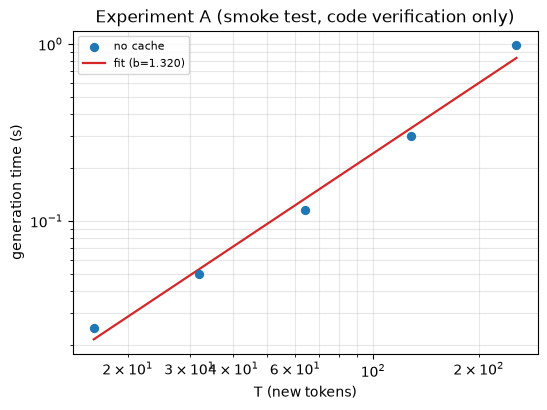

In [18]:
# --- 実験 A: べき乗則あてはめと判定 ---
_a_y_nocache = [float(np.mean(experiment_a_raw["nocache"][t])) for t in A_T_LEVELS]
_a_y_cache = [float(np.mean(experiment_a_raw["cache"][t])) for t in A_T_LEVELS]

experiment_a_fit_nocache = fit_power_law_exponent(A_T_LEVELS, _a_y_nocache)
experiment_a_fit_cache = fit_power_law_exponent(A_T_LEVELS, _a_y_cache)
print(f"b(キャッシュなし) = {experiment_a_fit_nocache.exponent:.4f} "
      f"+- {experiment_a_fit_nocache.exponent_stderr:.4f}")
print(f"b(キャッシュあり) = {experiment_a_fit_cache.exponent:.4f} "
      f"+- {experiment_a_fit_cache.exponent_stderr:.4f}")

_a_delta_b = experiment_a_fit_nocache.exponent - experiment_a_fit_cache.exponent
_a_sigma_delta_b = float(
    np.sqrt(experiment_a_fit_nocache.exponent_stderr**2 + experiment_a_fit_cache.exponent_stderr**2)
)
print(f"Delta_b = {_a_delta_b:.4f}, sigma_Delta_b = {_a_sigma_delta_b:.4f}, "
      f"Delta_b / sigma = {_a_delta_b / _a_sigma_delta_b:.2f}")

# 診断量: 理論上のべき指数の上限との対比(判定基準ではない)。
print(f"[診断量] 理論上限: キャッシュなし b<=3, キャッシュあり b<=2")

plot_log_log_fit(
    A_T_LEVELS, _a_y_nocache, experiment_a_fit_nocache.exponent, experiment_a_fit_nocache.coefficient,
    label="no cache", xlabel="T (new tokens)", ylabel="generation time (s)",
    title="Experiment A (smoke test, code verification only)",
)
plt.show()
# 本番実行後、このセルの出力(グラフ・数値)を踏まえて 8 節の考察を書く。
# このセル自体はスモークテストの数値であり、判定結果を結論として本文には記述しない。

In [19]:
# --- 実験 A: 本番水準・本番反復回数への外挿(CLAUDE.md 第 1 段階要件 1) ---
# スモークテストのべき乗則あてはめ(t = a * T^b)をそのまま使って本番水準の時間を見積もる。
# 各水準につきウォームアップ WARMUP_REPEATS 回 + PRODUCTION_A_REPEATS 回の呼び出しがある。
_a_calls_per_level = PRODUCTION_A_REPEATS + WARMUP_REPEATS
_a_extrapolated_nocache = sum(
    experiment_a_fit_nocache.coefficient * t**experiment_a_fit_nocache.exponent
    for t in PRODUCTION_A_T_LEVELS
) * _a_calls_per_level
_a_extrapolated_cache = sum(
    experiment_a_fit_cache.coefficient * t**experiment_a_fit_cache.exponent
    for t in PRODUCTION_A_T_LEVELS
) * _a_calls_per_level
EXPERIMENT_A_EXTRAPOLATED_SECONDS = _a_extrapolated_nocache + _a_extrapolated_cache
print(f"外挿: キャッシュなし {_a_extrapolated_nocache:.1f} 秒 + "
      f"キャッシュあり {_a_extrapolated_cache:.1f} 秒 = "
      f"{EXPERIMENT_A_EXTRAPOLATED_SECONDS:.1f} 秒"
      f"(水準 {PRODUCTION_A_T_LEVELS}、水準あたり {_a_calls_per_level} 回)")

外挿: キャッシュなし 278.2 秒 + キャッシュあり 49.9 秒 = 328.2 秒(水準 [128, 256, 512, 1024, 2048]、水準あたり 13 回)


### 7.3 実験 B: prefill と decode のバッチサイズ依存性の差

- **検証すること**: 総実行時間のバッチサイズに対する依存は、decode のほうが
  prefill より弱い(メモリ帯域律速の署名)。
- **対比量**: $\Delta b_B = b_{\text{decode}}(B) - b_{\text{prefill}}(B)$。
  $b(B)$ は総実行時間のバッチサイズ $B$ に対するべき指数。
  - **介入の直接作用点**: バッチサイズ $B$ が直接作用するのは 1 回の行列演算の
    形状(3.3 節の $N = B \cdot S$)であり、対比量($b(B)$)はこの演算を 1 回
    実行した総時間から求める。prefill・decode いずれも「1 回の呼び出し」を
    そのまま計測するため、作用点との距離は小さい。
- **判定基準**: $\Delta b_B < -2\sigma_{\Delta b_B}$ なら支持、$>
  +2\sigma_{\Delta b_B}$ なら反証、それ以外は判定不能。標準偏差の導出は実験 A と同じ
  (`fit_power_law_exponent`の`exponent_stderr`を誤差伝播で合成)。
- **水準**: バッチサイズを等比の刻みで 5 点、各点を反復計測する(反復回数は
  スモークテストと本番で異なり、セットアップセルの`SMOKE_B_REPEATS`・
  `PRODUCTION_B_REPEATS`で定義する)。
- **前提条件 P1_B**: 全バッチサイズで out-of-memory が発生しないこと。
- **診断量**(判定基準は設けない): 演算強度の理論値(3.3 節)、および重み
  読み出しバイト数を T4 GPU の公称メモリ帯域で割った下限時間との比。**この絶対値の
  一致は判定基準にしない**(実測の達成帯域は公称値の 7 割前後であり、真偽を
  判定できる形になりません)。

In [20]:
# --- 実験 B ---
# B_LEVELS・B_REPEATS・B_PREFILL_LEN はセットアップセル(SMOKE_TEST の定義の直後)で
# 定義済み(B_PREFILL_LEN が SMOKE_TEST に関わらず本番値に固定されている理由も
# そちらのコメントを参照)。

B_OOM_LEVELS: list[int] = []  # out-of-memory で前提不成立となりスキップした水準


def warmup_prefill(model, batch_size, seq_len, device):
    for _ in range(WARMUP_REPEATS):
        x = torch.randint(0, PROD_CONFIG["vocabulary_size"], (batch_size, seq_len), device=device)
        with torch.no_grad():
            model(x)
        sync(device)


def measure_prefill_once(model, batch_size, seq_len, device):
    x = torch.randint(0, PROD_CONFIG["vocabulary_size"], (batch_size, seq_len), device=device)
    sync(device)
    t0 = time.perf_counter()
    with torch.no_grad():
        model(x)
    sync(device)
    return time.perf_counter() - t0


def _one_decode_step(model, batch_size, prefill_len, device, timed: bool) -> float | None:
    '''prefill(計測しない)+ decode 1 ステップを行う。timed=True のときのみ
    decode ステップの時間を計測して返す(ウォームアップと本計測を同じ関数で
    共有し、実装の乖離を防ぐ)。
    '''
    kv_cache = KeyValueCache(PROD_CONFIG["num_layers"])
    context = torch.randint(0, PROD_CONFIG["vocabulary_size"], (batch_size, prefill_len), device=device)
    positions = torch.arange(prefill_len, device=device)
    with torch.no_grad():
        model(context, positions=positions, kv_cache=kv_cache)
    next_token = torch.randint(0, PROD_CONFIG["vocabulary_size"], (batch_size, 1), device=device)
    step_pos = torch.tensor([kv_cache.length], device=device)
    if not timed:
        with torch.no_grad():
            model(next_token, positions=step_pos, kv_cache=kv_cache)
        sync(device)
        return None
    sync(device)
    t0 = time.perf_counter()
    with torch.no_grad():
        model(next_token, positions=step_pos, kv_cache=kv_cache)
    sync(device)
    return time.perf_counter() - t0


def warmup_decode_step(model, batch_size, prefill_len, device):
    for _ in range(WARMUP_REPEATS):
        _one_decode_step(model, batch_size, prefill_len, device, timed=False)


def measure_decode_step_once(model, batch_size, prefill_len, device):
    return _one_decode_step(model, batch_size, prefill_len, device, timed=True)


# ウォームアップはバッチサイズごとにまとめて計測ループの前に行う(WARMUP_REPEATS 回、
# P0)。out-of-memory はウォームアップの時点で検出し、計測ループに進める前にその
# バッチサイズを除外する(計測開始後に一部の反復だけ欠けた不完全な水準を作らないため)。
_b_active_levels = list(B_LEVELS)
for _b in list(_b_active_levels):
    try:
        warmup_prefill(timing_model_a, _b, B_PREFILL_LEN, TIMING_DEVICE)
        warmup_decode_step(timing_model_a, _b, B_PREFILL_LEN, TIMING_DEVICE)
    except RuntimeError as e:
        if not is_oom_error(e):
            raise
        B_OOM_LEVELS.append(_b)
        _b_active_levels.remove(_b)
        print(f"[前提不成立] B={_b} でウォームアップ中に out-of-memory が発生したため"
              f"この水準をスキップする: {e}")

experiment_b_raw: dict[str, dict[int, list[float]]] = {
    "prefill": {b: [] for b in _b_active_levels},
    "decode": {b: [] for b in _b_active_levels},
}

# 計測は for 反復: for 条件: の順で行う(for 条件: for 反復: ではない)。1 つの条件の
# 反復をまとめて連続実行すると、一過性の擾乱が特定の条件に集中して入り、P0(変動係数)
# が不成立になりやすい。反復をまたいで条件(バッチサイズ)を切り替えることで、擾乱が
# 全条件に均等に散るようにする。ウォームアップ後に初めて out-of-memory が起きた場合
# (通常はウォームアップ時点で検出されるため稀)は、その時点でバッチサイズを打ち切り、
# それまでに記録した反復も破棄する(反復回数が水準間で不揃いにならないようにするため)。
for _rep in range(B_REPEATS):
    for _b in list(_b_active_levels):
        try:
            _prefill_time = measure_prefill_once(timing_model_a, _b, B_PREFILL_LEN, TIMING_DEVICE)
            _decode_time = measure_decode_step_once(timing_model_a, _b, B_PREFILL_LEN, TIMING_DEVICE)
        except RuntimeError as e:
            if not is_oom_error(e):
                raise
            B_OOM_LEVELS.append(_b)
            _b_active_levels.remove(_b)
            del experiment_b_raw["prefill"][_b]
            del experiment_b_raw["decode"][_b]
            print(f"[前提不成立] B={_b} で計測中(反復 {_rep + 1} 回目)に out-of-memory が"
                  f"発生したためこの水準を打ち切る(それまでの {_rep} 回分も破棄する): {e}")
            continue
        experiment_b_raw["prefill"][_b].append(_prefill_time)
        experiment_b_raw["decode"][_b].append(_decode_time)

for _b in _b_active_levels:
    for _cond in ("prefill", "decode"):
        _arr = np.array(experiment_b_raw[_cond][_b])
        print(f"B={_b:3d} {_cond:8s} mean={_arr.mean():.5f}s cv={_arr.std() / _arr.mean():.4f}")

B_P0_OOM_HOLDS = len(B_OOM_LEVELS) == 0
print(f"\n前提条件(全バッチサイズで OOM なし)成立: {B_P0_OOM_HOLDS}"
      f"(OOM が発生した水準: {B_OOM_LEVELS})")
print("\n[判定の一次情報 / experiment_b_raw]")
print(json.dumps(experiment_b_raw, ensure_ascii=False, indent=2))

B=  1 prefill  mean=0.01703s cv=0.1788
B=  1 decode   mean=0.00153s cv=0.1641
B=  2 prefill  mean=0.03212s cv=0.1593
B=  2 decode   mean=0.00299s cv=0.3899
B=  4 prefill  mean=0.06344s cv=0.1262
B=  4 decode   mean=0.00331s cv=0.1240
B=  8 prefill  mean=0.11687s cv=0.0949
B=  8 decode   mean=0.00424s cv=0.1194
B= 16 prefill  mean=0.23459s cv=0.1090
B= 16 decode   mean=0.00803s cv=0.1672

前提条件(全バッチサイズで OOM なし)成立: True(OOM が発生した水準: [])

[判定の一次情報 / experiment_b_raw]
{
  "prefill": {
    "1": [
      0.015305084001738578,
      0.0154859580215998,
      0.014644958020653576,
      0.01734487497014925,
      0.02414908300852403,
      0.016956541978288442,
      0.015295707969926298
    ],
    "2": [
      0.029427000030409545,
      0.0287202499457635,
      0.028110749961342663,
      0.034535415994469076,
      0.04367629101034254,
      0.03108104196144268,
      0.029296667024027556
    ],
    "4": [
      0.05675137502839789,
      0.055832749989349395,
      0.05509745900053531,
    

In [21]:
# --- 実験 B: 本番実行であることの保証 ---
# SMOKE_TEST=False のとき、実際に使った水準が PRODUCTION_* 定数と一致することを
# アサーションで確認する。OOM でスキップした水準がある場合、その水準は
# experiment_b_raw に記録されないため、「成功した水準 + OOM した水準」が
# PRODUCTION_B_LEVELS と一致することを確認する。
if not SMOKE_TEST:
    assert B_LEVELS == PRODUCTION_B_LEVELS, (
        f"本番実行のはずが B_LEVELS が PRODUCTION_B_LEVELS と一致しない: {B_LEVELS}"
    )
    assert B_REPEATS == PRODUCTION_B_REPEATS, (
        f"本番実行のはずが B_REPEATS が PRODUCTION_B_REPEATS と一致しない: {B_REPEATS}"
    )
    assert B_PREFILL_LEN == PRODUCTION_B_PREFILL_LEN, (
        f"本番実行のはずが B_PREFILL_LEN が PRODUCTION_B_PREFILL_LEN と一致しない: {B_PREFILL_LEN}"
    )
    for _cond in ("prefill", "decode"):
        assert set(experiment_b_raw[_cond].keys()) | set(B_OOM_LEVELS) == set(PRODUCTION_B_LEVELS), (
            f"experiment_b_raw[{_cond!r}] の水準(OOM 分を含む)が PRODUCTION_B_LEVELS と"
            f"一致しない: 成功={sorted(experiment_b_raw[_cond].keys())}, OOM={B_OOM_LEVELS}"
        )
        for _b, _vals in experiment_b_raw[_cond].items():
            assert len(_vals) == PRODUCTION_B_REPEATS, (
                f"experiment_b_raw[{_cond!r}][{_b}] の反復回数が PRODUCTION_B_REPEATS と"
                f"一致しない: {len(_vals)}"
            )
    print(f"[OK] 実験 B は本番水準(B_LEVELS={B_LEVELS}, B_REPEATS={B_REPEATS}, "
          f"B_PREFILL_LEN={B_PREFILL_LEN})で実行された")

prefill_B1     P0-a: 先頭=0.01515s 末尾=0.01880s 差=0.00366s 閾値=0.00657s 成立=True
               P0-b: 平均=0.01703s 標準誤差=0.00124s 比率=0.0730 成立=False
prefill_B2     P0-a: 先頭=0.02875s 末尾=0.03468s 差=0.00593s 閾値=0.01105s 成立=True
               P0-b: 平均=0.03212s 標準誤差=0.00209s 比率=0.0650 成立=False
prefill_B4     P0-a: 先頭=0.05589s 末尾=0.06809s 差=0.01220s 閾値=0.01730s 成立=True
               P0-b: 平均=0.06344s 標準誤差=0.00327s 比率=0.0515 成立=False
prefill_B8     P0-a: 先頭=0.10801s 末尾=0.12491s 差=0.01691s 閾値=0.02396s 成立=True
               P0-b: 平均=0.11687s 標準誤差=0.00453s 比率=0.0387 成立=True
prefill_B16    P0-a: 先頭=0.21690s 末尾=0.25428s 差=0.03739s 閾値=0.05523s 成立=True
               P0-b: 平均=0.23459s 標準誤差=0.01044s 比率=0.0445 成立=True
decode_B1      P0-a: 先頭=0.00143s 末尾=0.00147s 差=0.00004s 閾値=0.00054s 成立=True
               P0-b: 平均=0.00153s 標準誤差=0.00010s 比率=0.0670 成立=False
decode_B2      P0-a: 先頭=0.00217s 末尾=0.00395s 差=0.00179s 閾値=0.00252s 成立=True
               P0-b: 平均=0.00299s 標準誤差=0.00048s 比率=0.1592 成立=False
decode_B

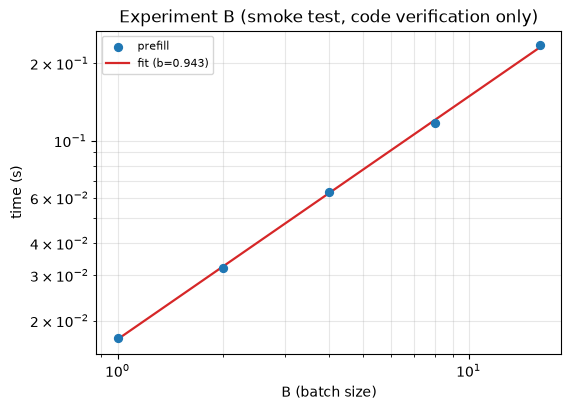

In [22]:
# --- 実験 B: 前提条件 P0-a・P0-b の確認(7.1 節) ---
_b_successful_levels = [b for b in B_LEVELS if b not in B_OOM_LEVELS]
_b_p0a_by_condition = {}
_b_p0b_by_condition = {}
for _cond, _by_b in experiment_b_raw.items():
    for _b, _vals in _by_b.items():
        _key = f"{_cond}_B{_b}"
        _b_p0a_by_condition[_key] = compute_p0a(_vals)
        _b_p0b_by_condition[_key] = compute_p0b(_vals)
        print(
            f"{_key:14s} P0-a: 先頭={_b_p0a_by_condition[_key]['head_mean']:.5f}s "
            f"末尾={_b_p0a_by_condition[_key]['tail_mean']:.5f}s "
            f"差={_b_p0a_by_condition[_key]['diff']:.5f}s "
            f"閾値={_b_p0a_by_condition[_key]['threshold']:.5f}s "
            f"成立={_b_p0a_by_condition[_key]['holds']}"
        )
        print(
            f"{'':14s} P0-b: 平均={_b_p0b_by_condition[_key]['mean']:.5f}s "
            f"標準誤差={_b_p0b_by_condition[_key]['stderr']:.5f}s "
            f"比率={_b_p0b_by_condition[_key]['ratio']:.4f} "
            f"成立={_b_p0b_by_condition[_key]['holds']}"
        )

B_P0A_HOLDS = all(v["holds"] for v in _b_p0a_by_condition.values())
B_P0B_HOLDS = all(v["holds"] for v in _b_p0b_by_condition.values())
B_P0_HOLDS = B_P0A_HOLDS and B_P0B_HOLDS
print(f"\nP0-a 全条件成立: {B_P0A_HOLDS} / P0-b 全条件成立: {B_P0B_HOLDS} / "
      f"P0(P0-a かつ P0-b)成立: {B_P0_HOLDS}")

_b_y_prefill = [float(np.mean(experiment_b_raw["prefill"][b])) for b in _b_successful_levels]
_b_y_decode = [float(np.mean(experiment_b_raw["decode"][b])) for b in _b_successful_levels]
experiment_b_fit_prefill = fit_power_law_exponent(_b_successful_levels, _b_y_prefill)
experiment_b_fit_decode = fit_power_law_exponent(_b_successful_levels, _b_y_decode)
print(f"b(prefill) = {experiment_b_fit_prefill.exponent:.4f} +- {experiment_b_fit_prefill.exponent_stderr:.4f}")
print(f"b(decode)  = {experiment_b_fit_decode.exponent:.4f} +- {experiment_b_fit_decode.exponent_stderr:.4f}")

_b_delta_b = experiment_b_fit_decode.exponent - experiment_b_fit_prefill.exponent
_b_sigma_delta_b = float(
    np.sqrt(experiment_b_fit_decode.exponent_stderr**2 + experiment_b_fit_prefill.exponent_stderr**2)
)
print(f"Delta_b_B = {_b_delta_b:.4f}, sigma = {_b_sigma_delta_b:.4f}, "
      f"Delta_b_B / sigma = {_b_delta_b / _b_sigma_delta_b:.2f}")

# 診断量: 演算強度の理論値、T4 公称帯域からの下限時間との比(判定基準ではない)。
_b_d_model = PROD_CONFIG["d_model"]
_b_weight_bytes = _b_d_model * _b_d_model * 4
_b_decode_ai = compute_arithmetic_intensity(2 * 1 * _b_d_model * _b_d_model, _b_weight_bytes + 1 * 2 * _b_d_model * 4)
print(f"[診断量] decode 1 層あたりの演算強度(概算): {_b_decode_ai:.3f} FLOPs/byte")

plot_log_log_fit(
    _b_successful_levels, _b_y_prefill, experiment_b_fit_prefill.exponent, experiment_b_fit_prefill.coefficient,
    label="prefill", xlabel="B (batch size)", ylabel="time (s)",
    title="Experiment B (smoke test, code verification only)",
)
plt.show()

In [23]:
# --- 実験 B: 本番水準への外挿(CLAUDE.md 第 1 段階要件 1) ---
_b_calls_per_level = PRODUCTION_B_REPEATS + WARMUP_REPEATS  # ウォームアップ WARMUP_REPEATS 回を含む
_b_extrapolated_prefill = sum(
    experiment_b_fit_prefill.coefficient * b**experiment_b_fit_prefill.exponent
    for b in PRODUCTION_B_LEVELS
) * _b_calls_per_level
_b_extrapolated_decode = sum(
    experiment_b_fit_decode.coefficient * b**experiment_b_fit_decode.exponent
    for b in PRODUCTION_B_LEVELS
) * _b_calls_per_level
EXPERIMENT_B_EXTRAPOLATED_SECONDS = _b_extrapolated_prefill + _b_extrapolated_decode
print(f"外挿: prefill {_b_extrapolated_prefill:.1f} 秒 + decode {_b_extrapolated_decode:.1f} 秒 = "
      f"{EXPERIMENT_B_EXTRAPOLATED_SECONDS:.1f} 秒"
      f"(水準 {PRODUCTION_B_LEVELS}、水準あたり {_b_calls_per_level} 回)")

外挿: prefill 142.6 秒 + decode 1.9 秒 = 144.5 秒(水準 [1, 4, 16, 64, 256]、水準あたり 33 回)


In [24]:
# --- 実験 B: 本番水準での必要メモリ量の閉形式による見積もり(較正は本番と同じ
# スケールで行うという規約に従い、閉形式で計算できる量は本番実行時まで未知にしない) ---
T4_MEMORY_BYTES = 16 * (1024**3)  # T4 GPU の公称メモリ容量(16 GB)

_b_prod_attention_score_bytes_per_layer = (
    PRODUCTION_B_LEVELS[-1] * PROD_CONFIG["num_heads"] * PRODUCTION_B_PREFILL_LEN**2 * 4
)
_b_prod_attention_score_bytes_total = _b_prod_attention_score_bytes_per_layer * PROD_CONFIG["num_layers"]
print(
    f"本番水準(batch_size={PRODUCTION_B_LEVELS[-1]}, prefill_len={PRODUCTION_B_PREFILL_LEN})での"
    f"Attention スコア行列のメモリ量:"
)
print(f"  1 層あたり: {_b_prod_attention_score_bytes_per_layer / 1e9:.2f} GB")
print(f"  {PROD_CONFIG['num_layers']} 層合計: {_b_prod_attention_score_bytes_total / 1e9:.2f} GB")
print(f"  T4 GPU 容量(16 GB)に対する比率: {_b_prod_attention_score_bytes_total / T4_MEMORY_BYTES:.1%}")
if _b_prod_attention_score_bytes_total > T4_MEMORY_BYTES:
    print("[警告] Attention スコア行列だけで T4 GPU の容量を超える。"
          "PRODUCTION_B_LEVELS の見直しが必要。")
else:
    print("[OK] Attention スコア行列のメモリ量は T4 GPU の容量に収まる見込み"
          "(重み・活性化・オプティマイザ状態は含まない概算であることに注意)。")

本番水準(batch_size=256, prefill_len=512)でのAttention スコア行列のメモリ量:
  1 層あたり: 2.15 GB
  4 層合計: 8.59 GB
  T4 GPU 容量(16 GB)に対する比率: 50.0%
[OK] Attention スコア行列のメモリ量は T4 GPU の容量に収まる見込み(重み・活性化・オプティマイザ状態は含まない概算であることに注意)。


### 7.4 実験 C: Key / Value ヘッド数の削減による高速化の系列長依存性

- **検証すること**: Key / Value ヘッド数の削減による decode の高速化は、
  系列長が長いほど大きい。
- **対比量**: $r(T) = t_{g=h}(T) / t_{g=1}(T)$($t_{g=h}$ は通常の多頭注意機構
  ($g=h$)の生成時間、$t_{g=1}$ は MQA($g=1$)の生成時間)としたときの
  $\Delta r = r(T_{\max}) - r(T_{\min})$。$T_{\min}$・$T_{\max}$ は等比の刻みの
  両端とする。
  - **介入の直接作用点**: Key / Value ヘッド数の削減が直接作用するのは、
    1 decode ステップあたりの KV キャッシュの読み出しバイト数(3.2・3.4 節)
    である。対比量 $r(T)$ は「生成全体の時間比」という下流の量であり、direct な
    作用点(1 ステップの読み出しバイト数)からは 1 段階離れている(生成全体の
    時間には、Key/Value 削減の影響を受けない Query 射影・出力射影・
    Feed-Forward Network の計算も含まれるため)。
- **判定基準**: $\Delta r > 2\sigma_{\Delta r}$ なら支持、$< -2\sigma_{\Delta r}$
  なら反証、それ以外は判定不能。$\sigma_{\Delta r}$ は反復計測から誤差伝播で
  導く。$r = a/b$(比)の相対標準誤差は、$a$・$b$ それぞれの相対標準誤差の
  二乗和の平方根

  $$
  \frac{\sigma_r}{r} = \sqrt{\left(\frac{\sigma_a / \sqrt{n}}{a}\right)^2
      + \left(\frac{\sigma_b / \sqrt{n}}{b}\right)^2}
  $$

  で求め($\sigma_a$・$\sigma_b$ は反復計測の標本標準偏差、$n$ は反復回数)、
  $T_{\min}$・$T_{\max}$ それぞれで得た $\sigma_{r(T_{\min})}$・
  $\sigma_{r(T_{\max})}$ を $\sigma_{\Delta r} = \sqrt{\sigma_{r(T_{\min})}^2
  + \sigma_{r(T_{\max})}^2}$ として合成する。
- この実験は学習を伴わない。重みはランダム初期化でよく、Key / Value ヘッド数だけが
  異なる同一構成のモデルで計測する。

In [25]:
# --- 実験 C ---
# C_T_SMALL・C_T_LARGE・C_REPEATS はセットアップセル(SMOKE_TEST の定義の直後)で定義済み。
C_PROMPT_LENGTH = 4

timing_model_mqa_c = convert_attention_to_grouped_query(
    timing_model_a, num_key_value_heads=1, init="random", seed=0
).to(TIMING_DEVICE)
timing_model_mqa_c.eval()


def warmup_decode_generate(model, t_new_tokens, prompt_length, device):
    assert prompt_length + t_new_tokens <= model.max_sequence_length, (
        f"prompt_length({prompt_length}) + t_new_tokens({t_new_tokens}) が "
        f"model.max_sequence_length({model.max_sequence_length}) を超えている"
    )
    for _ in range(WARMUP_REPEATS):
        x = torch.randint(0, PROD_CONFIG["vocabulary_size"], (1, prompt_length), device=device)
        with torch.no_grad():
            model.generate(x, max_new_tokens=t_new_tokens, temperature=0.0, use_cache=True)
        sync(device)


def measure_decode_generate_once(model, t_new_tokens, prompt_length, device):
    x = torch.randint(0, PROD_CONFIG["vocabulary_size"], (1, prompt_length), device=device)
    sync(device)
    t0 = time.perf_counter()
    with torch.no_grad():
        model.generate(x, max_new_tokens=t_new_tokens, temperature=0.0, use_cache=True)
    sync(device)
    # t_new_tokens をそのまま返す(呼び出し側が別途 C_T_SMALL/C_T_LARGE を再度参照するの
    # ではなく、計測ループが実際に使った値を関数自身の返り値として記録するため。
    # C_T_SMALL/C_T_LARGE 以外の値を誤って渡す呼び出し側の配線ミスも、この返り値を
    # PRODUCTION_C_T_SMALL/PRODUCTION_C_T_LARGE と照合すれば検出できる)。
    return t_new_tokens, time.perf_counter() - t0


_c_conditions = {
    "full_small": (timing_model_a, C_T_SMALL),
    "mqa_small": (timing_model_mqa_c, C_T_SMALL),
    "full_large": (timing_model_a, C_T_LARGE),
    "mqa_large": (timing_model_mqa_c, C_T_LARGE),
}

# ウォームアップは条件ごとにまとめて計測ループの前に行う(WARMUP_REPEATS 回、P0)。
for _name, (_model, _t) in _c_conditions.items():
    warmup_decode_generate(_model, _t, C_PROMPT_LENGTH, TIMING_DEVICE)

# 計測は for 反復: for 条件: の順で行う(for 条件: for 反復: ではない)。1 つの条件の
# 反復をまとめて連続実行すると、一過性の擾乱が特定の条件に集中して入り、P0(変動係数)
# が不成立になりやすい。反復をまたいで条件を切り替えることで、擾乱が全条件に均等に
# 散るようにする。
experiment_c_raw: dict[str, list[float]] = {name: [] for name in _c_conditions}
experiment_c_t_used: dict[str, int] = {}
for _rep in range(C_REPEATS):
    for _name, (_model, _t) in _c_conditions.items():
        _t_actual, _elapsed = measure_decode_generate_once(_model, _t, C_PROMPT_LENGTH, TIMING_DEVICE)
        experiment_c_raw[_name].append(_elapsed)
        experiment_c_t_used[_name] = _t_actual  # 条件内で不変(反復ごとに再確認するだけ)

for _name, _vals in experiment_c_raw.items():
    _arr = np.array(_vals)
    print(f"{_name:12s} T={experiment_c_t_used[_name]:4d} mean={_arr.mean():.5f}s "
          f"cv={_arr.std() / _arr.mean():.4f}")

print("\n[判定の一次情報 / experiment_c_raw, experiment_c_t_used]")
print(json.dumps({"times": experiment_c_raw, "t_used": experiment_c_t_used}, ensure_ascii=False, indent=2))

full_small   T=  16 mean=0.01741s cv=0.1966
mqa_small    T=  16 mean=0.01684s cv=0.1200
full_large   T= 256 mean=0.29717s cv=0.1324
mqa_large    T= 256 mean=0.28880s cv=0.1053

[判定の一次情報 / experiment_c_raw, experiment_c_t_used]
{
  "times": {
    "full_small": [
      0.016592750034760684,
      0.014443457999732345,
      0.016588292026426643,
      0.015750000020489097,
      0.016732916003093123,
      0.016185916028916836,
      0.025605416973121464
    ],
    "mqa_small": [
      0.01776170899393037,
      0.014628375007305294,
      0.01661725004669279,
      0.015341375023126602,
      0.017092333000618964,
      0.01532054104609415,
      0.02109958400251344
    ],
    "full_large": [
      0.29114441602723673,
      0.2651507499977015,
      0.27699591702548787,
      0.27668762498069555,
      0.27457629196578637,
      0.3071600840194151,
      0.3884458750253543
    ],
    "mqa_large": [
      0.24762529198778793,
      0.2719318339950405,
      0.26500395796028897,
      0.

In [26]:
# --- 実験 C: 本番実行であることの保証 ---
# C_T_SMALL・C_T_LARGE(セットアップセルで定義した設定値)と PRODUCTION_* の比較だけでは、
# 「time_decode_generate の呼び出しに実際に渡された値」が PRODUCTION_* と一致するかを
# 検証できない(設定値どうしの比較は、設定値の定義自体が PRODUCTION_* を参照している
# ため常に成立する自己参照になる)。experiment_c_t_used は関数の返り値であり、実際に
# 計測ループが使った生成長そのものなので、これを PRODUCTION_* と照合する。
if not SMOKE_TEST:
    assert (C_T_SMALL, C_T_LARGE) == (PRODUCTION_C_T_SMALL, PRODUCTION_C_T_LARGE), (
        "本番実行のはずが (C_T_SMALL, C_T_LARGE) が "
        f"(PRODUCTION_C_T_SMALL, PRODUCTION_C_T_LARGE) と一致しない: ({C_T_SMALL}, {C_T_LARGE})"
    )
    assert C_REPEATS == PRODUCTION_C_REPEATS, (
        f"本番実行のはずが C_REPEATS が PRODUCTION_C_REPEATS と一致しない: {C_REPEATS}"
    )
    _c_expected_t = {
        "full_small": PRODUCTION_C_T_SMALL,
        "mqa_small": PRODUCTION_C_T_SMALL,
        "full_large": PRODUCTION_C_T_LARGE,
        "mqa_large": PRODUCTION_C_T_LARGE,
    }
    for _name, _t in experiment_c_t_used.items():
        assert _t == _c_expected_t[_name], (
            f"experiment_c_t_used[{_name!r}](time_decode_generate に実際に渡された生成長)が "
            f"期待値({_c_expected_t[_name]})と一致しない: {_t}。C_T_SMALL/C_T_LARGE 以外の値が"
            "渡された疑いがある。"
        )
    for _name, _vals in experiment_c_raw.items():
        assert len(_vals) == PRODUCTION_C_REPEATS, (
            f"experiment_c_raw[{_name!r}] の反復回数が PRODUCTION_C_REPEATS と一致しない: {len(_vals)}"
        )
    print(f"[OK] 実験 C は本番水準(実際に使われた生成長: {experiment_c_t_used}, "
          f"C_REPEATS={C_REPEATS})で実行された")

In [27]:
# --- 実験 C: 前提条件 P0-a・P0-b の確認(7.1 節) ---
_c_p0a_by_condition = {}
_c_p0b_by_condition = {}
for _name, _vals in experiment_c_raw.items():
    _c_p0a_by_condition[_name] = compute_p0a(_vals)
    _c_p0b_by_condition[_name] = compute_p0b(_vals)
    print(
        f"{_name:12s} P0-a: 先頭={_c_p0a_by_condition[_name]['head_mean']:.5f}s "
        f"末尾={_c_p0a_by_condition[_name]['tail_mean']:.5f}s "
        f"差={_c_p0a_by_condition[_name]['diff']:.5f}s "
        f"閾値={_c_p0a_by_condition[_name]['threshold']:.5f}s "
        f"成立={_c_p0a_by_condition[_name]['holds']}"
    )
    print(
        f"{'':12s} P0-b: 平均={_c_p0b_by_condition[_name]['mean']:.5f}s "
        f"標準誤差={_c_p0b_by_condition[_name]['stderr']:.5f}s "
        f"比率={_c_p0b_by_condition[_name]['ratio']:.4f} "
        f"成立={_c_p0b_by_condition[_name]['holds']}"
    )

C_P0A_HOLDS = all(v["holds"] for v in _c_p0a_by_condition.values())
C_P0B_HOLDS = all(v["holds"] for v in _c_p0b_by_condition.values())
C_P0_HOLDS = C_P0A_HOLDS and C_P0B_HOLDS
print(f"\nP0-a 全条件成立: {C_P0A_HOLDS} / P0-b 全条件成立: {C_P0B_HOLDS} / "
      f"P0(P0-a かつ P0-b)成立: {C_P0_HOLDS}")

_c_full_small = np.array(experiment_c_raw["full_small"])
_c_mqa_small = np.array(experiment_c_raw["mqa_small"])
_c_full_large = np.array(experiment_c_raw["full_large"])
_c_mqa_large = np.array(experiment_c_raw["mqa_large"])


def _relative_stderr(arr: np.ndarray) -> float:
    return float((arr.std(ddof=1) / np.sqrt(len(arr))) / arr.mean())


r_small = float(_c_full_small.mean() / _c_mqa_small.mean())
r_large = float(_c_full_large.mean() / _c_mqa_large.mean())
delta_r = r_large - r_small

sigma_r_small = r_small * np.sqrt(_relative_stderr(_c_full_small) ** 2 + _relative_stderr(_c_mqa_small) ** 2)
sigma_r_large = r_large * np.sqrt(_relative_stderr(_c_full_large) ** 2 + _relative_stderr(_c_mqa_large) ** 2)
sigma_delta_r = float(np.sqrt(sigma_r_small**2 + sigma_r_large**2))

print(f"r(T={C_T_SMALL}) = {r_small:.4f}, r(T={C_T_LARGE}) = {r_large:.4f}")
print(f"Delta_r = {delta_r:.4f}, sigma_Delta_r = {sigma_delta_r:.4f}, "
      f"Delta_r / sigma = {delta_r / sigma_delta_r:.2f}")

full_small   P0-a: 先頭=0.01587s 末尾=0.01951s 差=0.00363s 閾値=0.00739s 成立=True
             P0-b: 平均=0.01741s 標準誤差=0.00140s 比率=0.0802 成立=False
mqa_small    P0-a: 先頭=0.01634s 末尾=0.01784s 差=0.00150s 閾値=0.00436s 成立=True
             P0-b: 平均=0.01684s 標準誤差=0.00082s 比率=0.0490 成立=True
full_large   P0-a: 先頭=0.27776s 末尾=0.32339s 差=0.04563s 閾値=0.08497s 成立=True
             P0-b: 平均=0.29717s 標準誤差=0.01606s 比率=0.0540 成立=False
mqa_large    P0-a: 先頭=0.26152s 末尾=0.31918s 差=0.05766s 閾値=0.06567s 成立=True
             P0-b: 平均=0.28880s 標準誤差=0.01241s 比率=0.0430 成立=True

P0-a 全条件成立: True / P0-b 全条件成立: False / P0(P0-a かつ P0-b)成立: False
r(T=16) = 1.0343, r(T=256) = 1.0290
Delta_r = -0.0053, sigma_Delta_r = 0.1204, Delta_r / sigma = -0.04


In [28]:
# --- 実験 C: 本番水準への外挿(CLAUDE.md 第 1 段階要件 1) ---
# 実験 C 自体は T が 2 点(smoke)のみで独自にべき乗則をあてはめるには点数が足りない。
# 実験 C が測るのは実験 A の「キャッシュあり」と同じ計測(KV キャッシュを用いた
# generate())であるため、実験 A で得たべき乗則あてはめ(experiment_a_fit_cache)を
# 流用して T_min・T_max での時間を外挿する。
_c_calls_per_level = PRODUCTION_C_REPEATS + WARMUP_REPEATS  # ウォームアップ WARMUP_REPEATS 回を含む
_c_extrapolated_per_level = sum(
    experiment_a_fit_cache.coefficient * t**experiment_a_fit_cache.exponent
    for t in (PRODUCTION_C_T_SMALL, PRODUCTION_C_T_LARGE)
)
EXPERIMENT_C_EXTRAPOLATED_SECONDS = _c_extrapolated_per_level * _c_calls_per_level * 2  # 多頭注意機構・MQA の 2 条件
print(f"外挿: T={PRODUCTION_C_T_SMALL}・{PRODUCTION_C_T_LARGE} x 2 条件"
      f"(多頭注意機構・MQA) x {_c_calls_per_level} 回 = "
      f"{EXPERIMENT_C_EXTRAPOLATED_SECONDS:.1f} 秒"
      "(実験 A のキャッシュありのべき乗則あてはめを流用)")

外挿: T=64・4096 x 2 条件(多頭注意機構・MQA) x 18 回 = 148.7 秒(実験 A のキャッシュありのべき乗則あてはめを流用)


### 7.5 実験 D: GQA への変換における平均プール初期化の効果

- **検証すること**: 多頭注意機構から GQA へ変換する際、平均プール初期化は
  ランダム初期化より、同一の追加学習ステップ数で低い bits-per-byte に到達する。
- **条件(主判定)**: GQA・平均プール初期化 + 追加学習 / GQA・ランダム初期化 +
  追加学習。この 2 条件は非埋め込みパラメータ数が完全に一致する(6 節で確認済み)。
- **条件(診断量)**: 元の多頭注意機構チェックポイント(追加学習なし)、
  MQA・平均プール初期化 + 追加学習。多頭注意機構との比較は Key / Value 射影の
  縮小により非埋め込みパラメータ数が揃わないため、**揃えられないことをここに
  明記したうえで参考値として報告する**。
- **Key / Value ヘッド数**: 元モデルのヘッド数 $h=8$ に対し、GQA は $g=4$、MQA は
  $g=1$。
- **対比量**: $\Delta\mathrm{bpb} = \mathrm{bpb}_{\text{random}} -
  \mathrm{bpb}_{\text{mean pool}}$($\mathrm{bpb}_{\text{random}}$ はランダム初期化、
  $\mathrm{bpb}_{\text{mean pool}}$ は平均プール初期化。いずれもシード平均、
  最終ステップの値)。
  - **介入の直接作用点**: この介入(初期化方式)が直接作用するのは初期化直後の
    重み(および、そこから計算される初期化直後の bits-per-byte)である。対比量は
    そこから追加学習を経た下流の量であり、直接の作用点からは 1 段階以上離れて
    いる。この距離を埋めるため、**初期化直後(追加学習ステップ数 0)の
    bits-per-byte を診断量として併記する**。
- **判定基準**: $\Delta\mathrm{bpb} > 2\sigma_{\Delta\mathrm{bpb}}$ なら支持、
  $< -2\sigma_{\Delta\mathrm{bpb}}$ なら反証、それ以外は判定不能。
  $\sigma_{\Delta\mathrm{bpb}} = \sqrt{\sigma_{\text{random}}^2/n +
  \sigma_{\text{mean pool}}^2/n}$($\sigma_{\text{random}}$・$\sigma_{\text{mean pool}}$
  は各条件のシード間標準偏差)、$n$ はシード数(3)。
- **前提条件**:
  - P1: 読み込んだ元チェックポイントの bits-per-byte が 008 の記録値(1.6622、
    008 8.1 節)と相対誤差 1% 以内で一致すること。
  - P2: 全条件で追加学習が実際に進んでいること。単一ステップの訓練損失は
    ミニバッチの引きによる雑音が大きいため(1 ステップだけの比較では、シードに
    よる違いが学習の進行ではなく最初のバッチの引きを反映してしまう)、**最初の
    数ステップの平均訓練損失と最後の数ステップの平均訓練損失を比較する**
    (`P2_AVERAGING_WINDOW`ステップ分の平均、最後の平均が最初の平均より低ければ
    進行とみなす)。
- **モデル**: `kojikojiprg/ai-theories-small-gpt-en`を起点とする(5.3 節で
  読み込み済み)。トークナイザは`kojikojiprg/ai-theories-tokenizer-en`
  (同梱されていないため)。
- **追加学習の最適化手法**: 007 で導入した AdamW・warmup + cosine スケジュールでは
  なく、006 と同じ Adam・固定学習率(3e-4)を使う。少数ステップの追加学習
  (uptraining)であり、両条件(平均プール初期化・ランダム初期化)に同一の
  最適化設定を等しく適用するため、この選択自体は対比量の成立に影響しない。
- **評価**: 006 の`evaluate_bits_per_byte()`と非重複の評価窓を用いる。
  `d_eval_text`(5.3 節)は`train_text`の内側から切り出した held-out スライスで
  あり、`val_text_008`(008 の検証集合、P1 の検証に使う)とも
  `d_train_text`(この実験の追加学習データ)とも重複しない。全条件で評価集合
  (`_full_eval_windows`)・追加学習ステップ数が完全に同一であることをアサーションで
  確認する。
  - **主判定への影響なし、診断量は楽観的に出ることの明記**: `d_eval_text`は
    `train_text`(008 が`base_model`の学習に使ったデータ)の内側から切り出した
    スライスであり、`base_model`は既に`d_eval_text`の内容を学習時に見ている。
    主判定(平均プール初期化 対 ランダム初期化)は両条件で評価集合が同一であり
    この影響は相殺されるため結論に影響しない。一方、診断量である
    初期化直後の bits-per-byte、および`D_ORIGINAL_BPB`(元の多頭注意機構
    チェックポイントの`d_eval_text`上の bits-per-byte)は、真に未知のテキストで
    評価した場合より **楽観的(低い)値** になっている可能性が高い。これらの
    診断量の絶対値に基づく主張はしない。

In [29]:
# --- 実験 D: 前提条件 P1(元チェックポイントの品質確認) ---
_p1_val_ids = encode_corpus(tokenizer, val_text_008)
_p1_eval_windows, _p1_eval_mask = make_evaluation_windows(_p1_val_ids, PROD_CONFIG["sequence_length"])
_p1_eval_bytes = len(val_text_008.encode("utf-8"))
D_P1_BPB = evaluate_bits_per_byte(base_model, _p1_eval_windows, _p1_eval_mask, _p1_eval_bytes, DEVICE, batch_size=16)
D_P1_REFERENCE_BPB = 1.6622  # 008 8.1 節の本番実行結果
D_P1_RELATIVE_ERROR = abs(D_P1_BPB - D_P1_REFERENCE_BPB) / D_P1_REFERENCE_BPB
print(f"P1: 元チェックポイントの bits-per-byte = {D_P1_BPB:.4f}"
      f"(008 記録値 {D_P1_REFERENCE_BPB}、相対誤差 {D_P1_RELATIVE_ERROR:.2%})")
D_P1_HOLDS = D_P1_RELATIVE_ERROR <= 0.01
print(f"P1 成立: {D_P1_HOLDS}")

P1: 元チェックポイントの bits-per-byte = 1.6681(008 記録値 1.6622、相対誤差 0.35%)
P1 成立: True


In [30]:
# --- 実験 D: 条件・学習ループの準備 ---
# D_NUM_STEPS はセットアップセル(SMOKE_TEST の定義の直後)で定義済み。
D_BATCH_SIZE = 8
D_SEEDS = [0, 1, 2]

# 全条件で共通の学習・評価データ(5.3 節で構築済み)。評価集合は _full_eval_windows /
# _full_eval_mask / _full_eval_bytes を全条件で共有する(下のアサーションで確認)。
# 本番は d_train_text 全体(SMOKE_D_TRAIN_TEXT_CHARS はセットアップセルで定義済み)。
D_TRAIN_TEXT_CHARS = SMOKE_D_TRAIN_TEXT_CHARS if SMOKE_TEST else len(d_train_text)
d_train_ids = encode_corpus(tokenizer, d_train_text[:D_TRAIN_TEXT_CHARS])
print(f"d_train_ids: {len(d_train_ids):,} トークン(smoke: 先頭 {D_TRAIN_TEXT_CHARS:,} 文字)")
print(f"評価窓: {_full_eval_windows.shape[0]} 個(全条件で共有)")

# 冗長な再計算の排除(7.6 節で検証): このセルで 1 回だけ符号化した d_train_ids・
# _full_eval_windows・_full_eval_mask を、以降の全条件・全シードの学習・評価ループで
# そのまま参照する(再符号化しない)。その証拠として、基となるメモリ領域のポインタを
# ここで記録しておく。
_d_train_ids_data_ptr_at_creation = d_train_ids.data_ptr()
_d_eval_windows_data_ptr_at_creation = _full_eval_windows.data_ptr()
_d_eval_mask_data_ptr_at_creation = _full_eval_mask.data_ptr()


def build_condition_model(num_key_value_heads: int, init: str, seed: int | None) -> GPTLanguageModel:
    return convert_attention_to_grouped_query(base_model, num_key_value_heads, init, seed=seed)


D_CONDITIONS = ["gqa_mean_pool", "gqa_random", "mqa_mean_pool_diagnostic"]
experiment_d_raw: dict[str, dict[str, list]] = {cond: {"seeds": []} for cond in D_CONDITIONS}

d_train_ids: 93,053 トークン(smoke: 先頭 400,000 文字)
評価窓: 469 個(全条件で共有)


In [31]:
# --- 実験 D: 診断条件(元の多頭注意機構チェックポイント、追加学習なし) ---
D_ORIGINAL_BPB = evaluate_bits_per_byte(
    base_model, _full_eval_windows, _full_eval_mask, _full_eval_bytes, DEVICE, batch_size=16
)
print(f"[診断量] 元の多頭注意機構チェックポイント(追加学習なし)の d_eval_text 上の bpb: "
      f"{D_ORIGINAL_BPB:.4f}")
print("[注記] このモデルは GQA/MQA と非埋め込みパラメータ数が揃わないため、参考値として扱う。")

[診断量] 元の多頭注意機構チェックポイント(追加学習なし)の d_eval_text 上の bpb: 1.3370
[注記] このモデルは GQA/MQA と非埋め込みパラメータ数が揃わないため、参考値として扱う。


In [32]:
# --- 実験 D: 主判定 2 条件 + 診断条件(MQA 平均プール)の学習ループ ---
_d_specs = {
    "gqa_mean_pool": {"num_key_value_heads": 4, "init": "mean_pool"},
    "gqa_random": {"num_key_value_heads": 4, "init": "random"},
    "mqa_mean_pool_diagnostic": {"num_key_value_heads": 1, "init": "mean_pool"},
}

_d_param_counts: dict[str, int] = {}
_d_trained_model_for_upload = None  # gqa_mean_pool, seed 0 を代表チェックポイントとして残す

# 前提条件 P2: 単一ステップの訓練損失は雑音が大きいため、最初と最後の数ステップの
# 平均で比較する(D_NUM_STEPS より大きくならないようにクリップする)。
P2_AVERAGING_WINDOW = min(3, D_NUM_STEPS)

for cond_name, spec in _d_specs.items():
    for seed in D_SEEDS:
        model = build_condition_model(spec["num_key_value_heads"], spec["init"], seed=seed)
        _d_param_counts.setdefault(cond_name, count_non_embedding_parameters(model))

        initial_bpb = evaluate_bits_per_byte(
            model, _full_eval_windows, _full_eval_mask, _full_eval_bytes, DEVICE, batch_size=16
        )
        history = train_language_model(
            model, d_train_ids, _full_eval_windows, _full_eval_mask, _full_eval_bytes,
            num_steps=D_NUM_STEPS, batch_size=D_BATCH_SIZE, sequence_length=PROD_CONFIG["sequence_length"],
            learning_rate=3e-4, eval_interval=D_NUM_STEPS, device=DEVICE, seed=seed,
        )
        final_bpb = history["eval_bits_per_byte"][-1]
        initial_loss_avg = float(np.mean(history["train_loss"][:P2_AVERAGING_WINDOW]))
        final_loss_avg = float(np.mean(history["train_loss"][-P2_AVERAGING_WINDOW:]))
        progressed = final_loss_avg < initial_loss_avg

        experiment_d_raw[cond_name]["seeds"].append({
            "seed": seed,
            "initial_bpb": initial_bpb,
            "final_bpb": final_bpb,
            "initial_train_loss": history["train_loss"][0],
            "final_train_loss": history["train_loss"][-1],
            "initial_train_loss_avg": initial_loss_avg,
            "final_train_loss_avg": final_loss_avg,
            "progressed": progressed,
            # train_language_model が実際に何ステップ学習したか(D_NUM_STEPS を再参照した
            # 値ではなく、返ってきた学習履歴 history["train_loss"] の実際の要素数)。
            "train_loss_len": len(history["train_loss"]),
        })
        print(f"{cond_name} seed={seed}: initial_bpb={initial_bpb:.4f} -> final_bpb={final_bpb:.4f} "
              f"(train_loss_avg(先頭{P2_AVERAGING_WINDOW})={initial_loss_avg:.4f} -> "
              f"train_loss_avg(末尾{P2_AVERAGING_WINDOW})={final_loss_avg:.4f}, progressed={progressed})")

        if cond_name == "gqa_mean_pool" and seed == 0:
            _d_trained_model_for_upload = model

print("\n[判定の一次情報 / experiment_d_raw]")
print(json.dumps(experiment_d_raw, ensure_ascii=False, indent=2))

gqa_mean_pool seed=0: initial_bpb=2.3261 -> final_bpb=1.8957 (train_loss_avg(先頭3)=6.2155 -> train_loss_avg(末尾3)=4.2918, progressed=True)


gqa_mean_pool seed=1: initial_bpb=2.3261 -> final_bpb=1.9070 (train_loss_avg(先頭3)=5.6039 -> train_loss_avg(末尾3)=4.5420, progressed=True)


gqa_mean_pool seed=2: initial_bpb=2.3261 -> final_bpb=1.9064 (train_loss_avg(先頭3)=5.9205 -> train_loss_avg(末尾3)=4.4039, progressed=True)


gqa_random seed=0: initial_bpb=3.3507 -> final_bpb=2.9590 (train_loss_avg(先頭3)=8.9930 -> train_loss_avg(末尾3)=7.3249, progressed=True)


gqa_random seed=1: initial_bpb=3.2944 -> final_bpb=2.9727 (train_loss_avg(先頭3)=9.0097 -> train_loss_avg(末尾3)=7.3908, progressed=True)


gqa_random seed=2: initial_bpb=3.3171 -> final_bpb=3.0146 (train_loss_avg(先頭3)=9.2072 -> train_loss_avg(末尾3)=7.4050, progressed=True)


mqa_mean_pool_diagnostic seed=0: initial_bpb=3.3982 -> final_bpb=2.9016 (train_loss_avg(先頭3)=9.0630 -> train_loss_avg(末尾3)=6.8726, progressed=True)


mqa_mean_pool_diagnostic seed=1: initial_bpb=3.3982 -> final_bpb=2.8712 (train_loss_avg(先頭3)=8.8695 -> train_loss_avg(末尾3)=6.9494, progressed=True)


mqa_mean_pool_diagnostic seed=2: initial_bpb=3.3982 -> final_bpb=2.8946 (train_loss_avg(先頭3)=9.0996 -> train_loss_avg(末尾3)=6.8153, progressed=True)

[判定の一次情報 / experiment_d_raw]
{
  "gqa_mean_pool": {
    "seeds": [
      {
        "seed": 0,
        "initial_bpb": 2.3261236092861584,
        "final_bpb": 1.895744857756109,
        "initial_train_loss": 6.591773509979248,
        "final_train_loss": 3.942706346511841,
        "initial_train_loss_avg": 6.215541044871013,
        "final_train_loss_avg": 4.291840314865112,
        "progressed": true,
        "train_loss_len": 15
      },
      {
        "seed": 1,
        "initial_bpb": 2.3261236092861584,
        "final_bpb": 1.9069675761039047,
        "initial_train_loss": 6.204634666442871,
        "final_train_loss": 4.6641998291015625,
        "initial_train_loss_avg": 5.6039449373881025,
        "final_train_loss_avg": 4.541958014170329,
        "progressed": true,
        "train_loss_len": 15
      },
      {
        "seed": 2,
  

In [33]:
# --- 実験 D: 本番実行であることの保証 ---
# D_TRAIN_TEXT_CHARS == len(d_train_text) だけの比較は自己参照になる。
# D_TRAIN_TEXT_CHARS 自体が「SMOKE_TEST でなければ len(d_train_text)」という式で
# 定義されているため、この比較は d_train_text がループ中に再代入されない限り常に
# 成立し、d_train_text[:D_TRAIN_TEXT_CHARS] が実際に符号化に使われたかどうかを
# 何も検証しない(train_language_model に渡す直前で別の値にすり替わっていても
# 検出できない)。
#
# 代わりに、実際に学習に渡された d_train_ids を復号し、d_train_text 全体と
# 内容が完全一致することを確認する(005・006 で確立した「符号化・復号のラウンド
# トリップが完全一致すること」の検証パターンと同じ)。d_train_ids は
# tokenizer.encode(d_train_text[:D_TRAIN_TEXT_CHARS]) の結果そのものであり、
# これを復号した文字列が d_train_text 全体と一致して初めて、d_train_text の
# 一部だけが符号化に使われていないことを独立に確認できる。
if not SMOKE_TEST:
    _d_train_text_decoded = tokenizer.decode(d_train_ids)
    assert _d_train_text_decoded == d_train_text, (
        "本番実行のはずが、実際に学習に渡された d_train_ids を復号したテキストが "
        "d_train_text 全体と一致しない(d_train_text の一部だけが符号化に使われた"
        f"疑いがある): 復号後の文字数={len(_d_train_text_decoded):,}, "
        f"d_train_text 全体の文字数={len(d_train_text):,}"
    )
    print(f"[OK] d_train_ids を復号したテキストが d_train_text 全体"
          f"({len(d_train_text):,} 文字)と完全一致した(train_language_model に "
          "実際に渡された学習データが本番水準であることを確認)")

    # D_NUM_STEPS == PRODUCTION_D_NUM_STEPS だけの比較も同様に自己参照になりうる
    # (train_language_model の呼び出しで num_steps=D_NUM_STEPS 以外の値が渡されて
    # いても検出できない)。history["train_loss"] は train_language_model が
    # 実際に何ステップ回したかを直接反映する返り値であり、これを記録した
    # train_loss_len(実験 D: 主判定 2 条件 + 診断条件の学習ループのセルを参照)を
    # PRODUCTION_D_NUM_STEPS と照合する。
    for _cond in D_CONDITIONS:
        for _run in experiment_d_raw[_cond]["seeds"]:
            assert _run["train_loss_len"] == PRODUCTION_D_NUM_STEPS, (
                f"{_cond} seed={_run['seed']}: train_language_model が実際に学習した"
                f"ステップ数(history['train_loss'] の要素数 {_run['train_loss_len']})が "
                f"PRODUCTION_D_NUM_STEPS({PRODUCTION_D_NUM_STEPS})と一致しない。"
                "num_steps=D_NUM_STEPS 以外の値が渡された疑いがある。"
            )
    print(f"[OK] 実験 D の全 {sum(len(experiment_d_raw[c]['seeds']) for c in D_CONDITIONS)} "
          f"run で、実際の学習ステップ数(history['train_loss'] の長さ)が "
          f"PRODUCTION_D_NUM_STEPS({PRODUCTION_D_NUM_STEPS})と一致した")

In [34]:
# --- 実験 D: 不変条件 P2(全条件で追加学習が実際に進んでいること) ---
D_P2_HOLDS = all(
    run["progressed"] for cond in D_CONDITIONS for run in experiment_d_raw[cond]["seeds"]
)
print(f"P2(全条件で末尾{P2_AVERAGING_WINDOW}ステップ平均損失 < 先頭{P2_AVERAGING_WINDOW}ステップ平均損失)成立: {D_P2_HOLDS}")

# --- 不変条件: 実験 D の主判定 2 条件で非埋め込みパラメータ数が完全一致すること ---
assert _d_param_counts["gqa_mean_pool"] == _d_param_counts["gqa_random"], (
    "実験 D の主判定条件で非埋め込みパラメータ数が一致しない"
)
print(f"[OK] 主判定条件の非埋め込みパラメータ数が一致: {_d_param_counts['gqa_mean_pool']:,}")

P2(全条件で末尾3ステップ平均損失 < 先頭3ステップ平均損失)成立: True
[OK] 主判定条件の非埋め込みパラメータ数が一致: 2,886,912


In [35]:
# --- 実験 D: 対比量の計算 ---
_d_mean_final = np.array([r["final_bpb"] for r in experiment_d_raw["gqa_mean_pool"]["seeds"]])
_d_random_final = np.array([r["final_bpb"] for r in experiment_d_raw["gqa_random"]["seeds"]])
_d_mean_initial = np.array([r["initial_bpb"] for r in experiment_d_raw["gqa_mean_pool"]["seeds"]])
_d_random_initial = np.array([r["initial_bpb"] for r in experiment_d_raw["gqa_random"]["seeds"]])

n_seeds = len(D_SEEDS)
delta_bpb = float(_d_random_final.mean() - _d_mean_final.mean())
sigma_delta_bpb = float(
    np.sqrt(_d_random_final.std(ddof=1) ** 2 / n_seeds + _d_mean_final.std(ddof=1) ** 2 / n_seeds)
)
print(f"Delta_bpb(最終) = {delta_bpb:.4f}, sigma = {sigma_delta_bpb:.4f}, "
      f"Delta_bpb / sigma = {delta_bpb / sigma_delta_bpb:.2f}" if sigma_delta_bpb > 0 else "sigma=0")

# 診断量: 初期化直後(追加学習ステップ数 0)の bpb(介入の直接作用点)。
print(f"\n[診断量] 初期化直後の bpb: mean_pool={_d_mean_initial.mean():.4f} "
      f"(seed毎={_d_mean_initial.tolist()}), random={_d_random_initial.mean():.4f} "
      f"(seed毎={_d_random_initial.tolist()})")

_d_mqa_final = np.array([r["final_bpb"] for r in experiment_d_raw["mqa_mean_pool_diagnostic"]["seeds"]])
print(f"[診断量] MQA・平均プール初期化 + 追加学習の最終 bpb(seed平均): {_d_mqa_final.mean():.4f}"
      "(多頭注意機構と非埋め込みパラメータ数が揃わないため参考値)")

Delta_bpb(最終) = 1.0791, sigma = 0.0171, Delta_bpb / sigma = 63.06

[診断量] 初期化直後の bpb: mean_pool=2.3261 (seed毎=[2.3261236092861584, 2.3261236092861584, 2.3261236092861584]), random=3.3208 (seed毎=[3.3507134120703728, 3.294403090067525, 3.317141630801045])
[診断量] MQA・平均プール初期化 + 追加学習の最終 bpb(seed平均): 2.8891(多頭注意機構と非埋め込みパラメータ数が揃わないため参考値)


### 7.6 外挿値の合計とセッション予算との比較

5.3 節(符号化・追加学習・評価)の小計に、実験 A・B・C 自身の時間計測の外挿値を
合算し、セッション予算との比較を確定させる(CLAUDE.md 第 1 段階要件 1)。

**この外挿値の絶対値はデバイス依存であることに注意する。** 5.3 節は`DEVICE`
(ローカルでは MPS)、実験 A・B・C は`TIMING_DEVICE`(ローカルでは CPU)で測った
係数を、本番の Google Colab T4 GPU(CUDA)にそのまま適用している。べき乗則の
**指数** はハードウェアが変わってもある程度は保たれると期待できるが、**係数**
(1 回あたりの絶対時間)はデバイスによって大きく異なる。特に実験 C は本番で
decode ステップが延べ約 13 万回(`PRODUCTION_C_REPEATS` x 2 条件 x
(`PRODUCTION_C_T_SMALL` + `PRODUCTION_C_T_LARGE`))に達し、T4 GPU では
1 ステップあたりのカーネル起動オーバーヘッド(CPU 実行にはない要素)が支配項に
なりうる。したがって、以下の外挿値の合計は **セッション予算に収まるかどうかの
目安** として使い、本番実行後の実測値で必ず更新すること(この後の実験セルの
再実行や再計測は求めない。8 節の考察執筆時に、実際にかかった時間をあわせて
記録すればよい)。

In [36]:
TOTAL_EXTRAPOLATED_SECONDS = (
    _subtotal_5_3_seconds
    + EXPERIMENT_A_EXTRAPOLATED_SECONDS
    + EXPERIMENT_B_EXTRAPOLATED_SECONDS
    + EXPERIMENT_C_EXTRAPOLATED_SECONDS
)
print(f"5.3 節(符号化・追加学習・評価)小計: {_subtotal_5_3_seconds:.1f} 秒")
print(f"実験 A: {EXPERIMENT_A_EXTRAPOLATED_SECONDS:.1f} 秒")
print(f"実験 B: {EXPERIMENT_B_EXTRAPOLATED_SECONDS:.1f} 秒")
print(f"実験 C: {EXPERIMENT_C_EXTRAPOLATED_SECONDS:.1f} 秒")
print(f"合計: {TOTAL_EXTRAPOLATED_SECONDS:.1f} 秒 / セッション予算: {SESSION_BUDGET_SECONDS} 秒")
if TOTAL_EXTRAPOLATED_SECONDS > SESSION_BUDGET_SECONDS:
    print("[警告] 外挿値の合計がセッション予算を超える。本番実行前にステップ数・水準数の見直しが必要。")
else:
    print("[OK] 外挿値の合計はセッション予算に対して十分な余裕がある。")

5.3 節(符号化・追加学習・評価)小計: 271.6 秒
実験 A: 328.2 秒
実験 B: 144.5 秒
実験 C: 148.7 秒
合計: 893.0 秒 / セッション予算: 7200 秒
[OK] 外挿値の合計はセッション予算に対して十分な余裕がある。


### 7.7 冗長な再計算の排除の確認

`d_train_ids`・`_full_eval_windows`・`_full_eval_mask`は 5.3 節で 1 回だけ符号化し、
実験 D の条件 x シードの全 9 回の学習・評価ループでそのまま再利用した(再符号化して
いない)。基となるメモリ領域のポインタ(`Tensor.data_ptr()`)が、5.3 節での作成時と
実験 D のループを終えた現在とで一致することを確認する。

In [37]:
assert d_train_ids.data_ptr() == _d_train_ids_data_ptr_at_creation, (
    "d_train_ids が実験 D のループ中に再代入・再符号化された可能性がある"
)
assert _full_eval_windows.data_ptr() == _d_eval_windows_data_ptr_at_creation
assert _full_eval_mask.data_ptr() == _d_eval_mask_data_ptr_at_creation
print("[OK] d_train_ids・_full_eval_windows・_full_eval_mask は、5.3 節で符号化した"
      "同一のメモリ領域を実験 D の全 9 回の学習・評価ループで再利用した"
      "(再符号化・再計算していない)")

[OK] d_train_ids・_full_eval_windows・_full_eval_mask は、5.3 節で符号化した同一のメモリ領域を実験 D の全 9 回の学習・評価ループで再利用した(再符号化・再計算していない)


### 7.8 実験 D のチェックポイントのアップロード

判定の一次情報(実験 A・B・C の条件 x 水準 x 反復の生の実行時間、実験 D の条件 x
シードの学習曲線・bits-per-byte)は 7.2〜7.5 節の各計測セルの直後で既にセル出力へ
全件印字済みであり、それが唯一の記録である(ファイルへの書き出しは行わない)。

一方、実験 D の代表チェックポイント(GQA・平均プール初期化・シード 0)は、014・015
など後続トピックの入力になるモデルであるため、Hugging Face Hub の
`kojikojiprg/ai-theories-small-gpt-en`の`gqa`ブランチへアップロードする。ローカルへ
ダウンロードしてからスクリプト経由でアップロードする迂回はせず、**このノートブックの
アップロードセルから、Google Colab Secrets の`HF_TOKEN`を使って直接アップロードする。**

アップロードは`UPLOAD_ARTIFACTS`フラグ(既定`False`、`SMOKE_TEST`とは独立)で守り、
Colab Secrets から`HF_TOKEN`が取得できない場合は例外を送出せずスキップし、アップロード
後は`list_repo_files`で意図したファイルが実際に存在することを確認する。

In [38]:
# 実験 D の代表チェックポイント(GQA・平均プール初期化・シード 0)を一時ファイルに
# 書き出す。state_dict は実行時のデバイス(本番の Google Colab では CUDA)に紐づく
# テンソルを持つため、保存前に全テンソルを CPU へ移す(Hugging Face Hub 上の
# アーティファクトとしてデバイスに依存せず後続トピックから扱えるようにするため)。
import tempfile

_gqa_checkpoint_path = Path(tempfile.mkdtemp()) / "010_gqa_uptrained.pt"
# tie_embeddings=True により token_embedding.weight と lm_head.weight は同一の
# ストレージを共有している。しかし state_dict() はパラメータごとに .detach() を
# 呼ぶため、共有元が同じでも Python オブジェクトとしては別物になる(id() では
# 共有を検出できない)。さらに、共有元が同じでも .cpu() を個別に呼ぶと(異なる
# device 間の転送は必ず新しいストレージを割り当てるため)共有関係が失われ、
# 埋め込み行列が 2 重に保存されてファイルサイズが不必要に増える。そこで、
# 元のストレージのポインタ(data_ptr())ごとに 1 回だけ .cpu() を呼び、
# 同じ data_ptr() には同じ変換後テンソルを再利用することで共有関係を保つ。
_cpu_tensor_cache: dict[int, torch.Tensor] = {}
_gqa_state_dict_cpu: dict[str, torch.Tensor] = {}
for _key, _value in _d_trained_model_for_upload.state_dict().items():
    _ptr = _value.data_ptr()
    if _ptr not in _cpu_tensor_cache:
        _cpu_tensor_cache[_ptr] = _value.detach().cpu()
    _gqa_state_dict_cpu[_key] = _cpu_tensor_cache[_ptr]
torch.save(_gqa_state_dict_cpu, _gqa_checkpoint_path)

# 保存の往復に欠損がないことの検証: 保存したファイルを map_location="cpu" で
# 読み戻し、元のモデルの state_dict と全テンソルが一致することを確認する。
_gqa_state_dict_reloaded = torch.load(_gqa_checkpoint_path, map_location="cpu")
assert _gqa_state_dict_reloaded.keys() == _gqa_state_dict_cpu.keys(), (
    "読み戻した state_dict のキー集合が元のモデルと一致しない"
)
for _key in _gqa_state_dict_cpu:
    assert torch.equal(_gqa_state_dict_reloaded[_key], _gqa_state_dict_cpu[_key]), (
        f"読み戻した state_dict のテンソルが元のモデルと一致しない: {_key}"
    )
print(f"[OK] 保存・読み戻し(map_location=\"cpu\")で全 {len(_gqa_state_dict_cpu)} テンソルが完全一致")

_checkpoint_bytes = _gqa_checkpoint_path.stat().st_size
_checkpoint_sha256 = hashlib.sha256(_gqa_checkpoint_path.read_bytes()).hexdigest()
print(f"書き出し先(一時ファイル): {_gqa_checkpoint_path}")
print(f"バイト数: {_checkpoint_bytes:,}")
print(f"SHA-256: {_checkpoint_sha256}")

[OK] 保存・読み戻し(map_location="cpu")で全 39 テンソルが完全一致
書き出し先(一時ファイル): /var/folders/c3/qxjqpmrs7kgbknk2j7_c8g3c0000gn/T/tmpjk1e6gue/010_gqa_uptrained.pt
バイト数: 19,948,905
SHA-256: d75836b0555c169a5e34b06d4adb5f2bb63c27b997bdb104c8997a2a4a96ab97


In [39]:
# --- Hugging Face Hub へのアップロード(既定ではスキップする) ---
UPLOAD_ARTIFACTS = False  # こうじさんが Colab で意図的に True にしたときのみアップロードする(SMOKE_TEST とは独立)。

GQA_TARGET_REPO_ID = "kojikojiprg/ai-theories-small-gpt-en"
GQA_TARGET_BRANCH = "gqa"
GQA_TOKENIZER_REPO_ID = "kojikojiprg/ai-theories-tokenizer-en"


def fetch_main_config_for_gqa(num_key_value_heads: int) -> dict:
    '''main ブランチの config.json を取得し、num_key_value_heads を加える。

    d_model・num_layers・num_heads などのフィールドを手で列挙して再構築すると、main 側に
    フィールドが増えたとき(swiglu_d_ff・dropout・tie_embeddings など)に本セルの更新漏れで
    gqa ブランチの config.json だけが値を欠いたまま取り残される。直接取得してそのまま
    コピーすれば、この種の更新漏れが構造的に起きない。
    '''
    from huggingface_hub import hf_hub_download

    _config_path = hf_hub_download(
        repo_id=GQA_TARGET_REPO_ID, filename="config.json", revision="main"
    )
    _config = json.loads(Path(_config_path).read_text(encoding="utf-8"))
    _config["num_key_value_heads"] = num_key_value_heads
    return _config


def build_gqa_model_card(config: dict, checkpoint_sha256: str) -> str:
    '''モデルカード(日本語メイン・英語併記)を作る。'''
    _num_heads = config["num_heads"]
    _num_key_value_heads = config["num_key_value_heads"]
    return f'''---
language: en
license: mit
tags:
- ai-theories
- gpt
- gqa
- scratch-implementation
---

# ai-theories 標準小型 GPT モデル(英語・Grouped-Query Attention、ブランチ: `{GQA_TARGET_BRANCH}`)

`ai-theories`(https://github.com/kojikojiprg/ai-theories)プロジェクトの成果物。
[kojikojiprg/ai-theories-small-gpt-en](https://huggingface.co/kojikojiprg/ai-theories-small-gpt-en)
の `main` ブランチ(通常の多頭注意機構、ヘッド数 {_num_heads})を起点に、
[010. KV キャッシュと推論の計算量](https://github.com/kojikojiprg/ai-theories/blob/main/theories/03_efficient_training/010_kv_cache_and_inference_compute.ipynb)
の実験 D で Key / Value ヘッド数を {_num_key_value_heads} に削減し(Grouped-Query
Attention)、平均プール初期化(Ainslie et al., "GQA: Training Generalized Multi-Query
Transformer Models from Multi-Head Checkpoints", EMNLP 2023 の uptraining)の後に
追加学習したチェックポイント(シード 0 の代表例)。

研究・教育目的のモデルであり、品質保証は行っていない。商用・実運用での利用は想定しない。

## 構成

`config.json` を参照。`num_key_value_heads` が `num_heads` より小さい点のみ、
`main` ブランチと異なる。

**トークナイザはこのリポジトリ・ブランチには同梱していない。**
[kojikojiprg/ai-theories-tokenizer-en](https://huggingface.co/{GQA_TOKENIZER_REPO_ID})
を使用すること(`main` ブランチと共通)。

## 検証情報

- SHA-256(`model_state.pt`): `{checkpoint_sha256}`

## 関連ノートブック

- [010. KV キャッシュと推論の計算量](https://github.com/kojikojiprg/ai-theories/blob/main/theories/03_efficient_training/010_kv_cache_and_inference_compute.ipynb)
'''


if not UPLOAD_ARTIFACTS:
    print("UPLOAD_ARTIFACTS=False のため、Hugging Face Hub へのアップロードをスキップした。")
else:
    _hf_token = None
    try:
        from google.colab import userdata

        _hf_token = userdata.get("HF_TOKEN")
    except Exception as _e:  # noqa: BLE001  # Colab Secrets 未設定・非 Colab 環境など理由を問わずスキップする
        print(f"Colab Secrets から HF_TOKEN を取得できなかったため、アップロードをスキップした: {_e!r}")

    if _hf_token:
        # gqa_mean_pool の Key / Value ヘッド数(実験 D の条件設定、_d_specs を参照)を
        # そのまま使う(ここで数値を独自に書き直さない)。
        _gqa_num_key_value_heads = _d_specs["gqa_mean_pool"]["num_key_value_heads"]
        _gqa_config = fetch_main_config_for_gqa(_gqa_num_key_value_heads)
        assert _gqa_config["num_key_value_heads"] < _gqa_config["num_heads"], (
            f"num_key_value_heads({_gqa_config['num_key_value_heads']}) が "
            f"num_heads({_gqa_config['num_heads']})未満ではない。"
            "GQA への変換になっていない疑いがある。"
        )
        _gqa_card_text = build_gqa_model_card(_gqa_config, _checkpoint_sha256)

        from huggingface_hub import HfApi

        _api = HfApi(token=_hf_token)
        _api.create_branch(repo_id=GQA_TARGET_REPO_ID, branch=GQA_TARGET_BRANCH, exist_ok=True)
        _api.upload_file(
            path_or_fileobj=str(_gqa_checkpoint_path),
            path_in_repo="model_state.pt",
            repo_id=GQA_TARGET_REPO_ID,
            revision=GQA_TARGET_BRANCH,
        )
        _api.upload_file(
            path_or_fileobj=json.dumps(_gqa_config, indent=2, ensure_ascii=False).encode("utf-8"),
            path_in_repo="config.json",
            repo_id=GQA_TARGET_REPO_ID,
            revision=GQA_TARGET_BRANCH,
        )
        _api.upload_file(
            path_or_fileobj=_gqa_card_text.encode("utf-8"),
            path_in_repo="README.md",
            repo_id=GQA_TARGET_REPO_ID,
            revision=GQA_TARGET_BRANCH,
        )

        # upload_file が例外を送出しなかったことだけをアップロード成功の根拠にせず、
        # list_repo_files で意図したファイルが実際に存在することを確認する。
        _uploaded_files = set(
            _api.list_repo_files(repo_id=GQA_TARGET_REPO_ID, revision=GQA_TARGET_BRANCH)
        )
        for _expected in ("model_state.pt", "config.json", "README.md"):
            assert _expected in _uploaded_files, (
                f"アップロード後の確認: {_expected} が "
                f"{GQA_TARGET_REPO_ID}@{GQA_TARGET_BRANCH} に見つからない"
            )
        print(
            "[OK] アップロード完了かつ list_repo_files で存在を確認した: "
            f"https://huggingface.co/{GQA_TARGET_REPO_ID}/tree/{GQA_TARGET_BRANCH}"
        )

UPLOAD_ARTIFACTS=False のため、Hugging Face Hub へのアップロードをスキップした。


## 8. 結果・考察 / Results and Discussion

**この節は、本番実行(Google Colab T4 GPU、`SMOKE_TEST=False`)後に、実際の
セル出力と数値を突き合わせて記述する。** 以下は、その際に書く内容の見出しと
箇条書きのみである(CLAUDE.md の二段階運用、第 1 段階の規約に従い、
スモークテストの数値に基づく結論は書かない)。

### 8.1 実験 A: KV キャッシュによる生成時間の次数の低下

- $b_{\text{no cache}}$・$b_{\text{cache}}$の実測値と標準誤差
- $\Delta b$ と判定(支持 / 反証 / 判定不能)
- 診断量(各 $T$ での実測時間、理論上のべき指数の上限との対比)

### 8.2 実験 B: prefill と decode のバッチサイズ依存性の差

- $b_{\text{prefill}}(B)$・$b_{\text{decode}}(B)$の実測値と標準誤差
- $\Delta b_B$ と判定
- 診断量(演算強度の理論値、T4 公称帯域からの下限時間との比)

### 8.3 実験 C: Key / Value ヘッド数の削減による高速化の系列長依存性

- $r(T_{\min})$・$r(T_{\max})$の実測値
- $\Delta r$ と判定

### 8.4 実験 D: GQA への変換における平均プール初期化の効果

- 前提条件 P1・P2 の成否
- $\Delta\mathrm{bpb}$(主判定)と判定
- 診断量(初期化直後の bpb、MQA・元チェックポイントの参考値)

### 8.5 全体を通した考察

- 4 つの実験を通じて、KV キャッシュ・prefill / decode の非対称性・GQA / MQA が
  実際の計算資源にどう効くかの一貫した描像
- 本番実行環境(Google Colab T4 GPU)固有の注意点があれば記載